# FYP - AI Model Training (SP500 Models)
This file is about training the model of S&P 500 index.
### Contents
1. Installing the package
2. Importing the libraries
3. Some useful function
4. Complit and fit model function
5. Plot and print history function
6. Set a seed
7. Data preparing
8. Data processing
9. Model Training
    1. 1st Training - Building model
    2. 2nd Training - Parameter turning
    3. 3rd Training - Reducing Overfitting
    4. 4th Training - Feature selection
10. Model Evaluation
    1. Retain model
    2. Showing evaluated model's result
11. Export Models

## 1. Installing the package
The talib package is not installed by default in the Colab environment.

In [1]:
# Download and extract the TA-Lib source code.
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
# Configure the environment and compile and install.
%cd ta-lib
!./configure --prefix=/usr
!make
!make install
# Install the TA-Lib package for Python.
!pip install TA-Lib

--2026-04-16 14:37:34--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:d95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.12.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2026-04-16 14:37:34--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.13.149, 104.18.12.149, 2606:4700::6812:c95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://psychz.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2026-04-16 14:37:34--  http://psychz.dl.sourcefo

## 2. Importing the libraries

In [2]:
import os
import talib
import random
import keras
import yfinance as yf
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from keras.optimizers import Adam
from keras.losses import Huber
from keras.metrics import MeanAbsoluteError, RootMeanSquaredError, MeanSquaredError
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, BatchNormalization, Bidirectional
from tensorflow.keras.regularizers import l2, l1
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## 3. Some useful function

In [3]:
def scale_and_prepare_samples(df_features):
    # Scaling the datasets (training set, validation set, test set))
    scaler = MinMaxScaler(feature_range=(0,1))
    transform_train = {}
    transform_validation = {}
    transform_test = {}
    # use df_features computed above (shape: n x 3)
    tr = df_features['Train'].values
    va = df_features['Validation'].values
    te = df_features['Test'].values
    # fit on training set
    transform_train = scaler.fit_transform(tr)
    transform_validation = scaler.transform(va) if len(va) > 0 else np.empty((0, tr.shape[1]))
    transform_test = scaler.transform(te) if len(te) > 0 else np.empty((0, tr.shape[1]))
    return transform_train, transform_validation, transform_test, scaler

def prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step):
    """Prepare LSTM training/validation/test samples from the transformed data."""
    X_train = []
    y_train = []
    X_validation = []
    y_validation = []
    X_test = []
    y_test = []
    tr_len = transform_train.shape[0]
    for i in range(time_step, tr_len):
        X_train.append(transform_train[i-time_step:i, :])  # use all features
        y_train.append(transform_train[i, 0])  # predict Close (column 0)
    X_train, y_train = np.array(X_train), np.array(y_train)
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], features_num)) if X_train.size else np.empty((0, time_step, features_num))
    val_len = transform_validation.shape[0]
    for i in range(time_step, val_len):
        X_validation.append(transform_validation[i-time_step:i, :])
        y_validation.append(transform_validation[i, 0])
    X_validation, y_validation = np.array(X_validation), np.array(y_validation)
    X_validation = X_validation.reshape((X_validation.shape[0], X_validation.shape[1], features_num)) if X_validation.size else np.empty((0, time_step, features_num))
    te_len = transform_test.shape[0]
    for i in range(time_step, te_len):
        X_test.append(transform_test[i-time_step:i, :])
        y_test.append(transform_test[i, 0])
    X_test, y_test = np.array(X_test), np.array(y_test)
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], features_num)) if X_test.size else np.empty((0, time_step, features_num))
    return X_train, y_train, X_validation, y_validation, X_test, y_test

## 4. Complit and fit model function

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)
]

def compile_and_fit_model(model, X_train, y_train, X_validation, y_validation):
    """ Compiles and fits model, returning the history """
    model.compile(
        optimizer = Adam(learning_rate=0.001),
        loss = Huber(),
        metrics = [
            MeanAbsoluteError(name='mae'),
            RootMeanSquaredError(name='rmse'),
            MeanSquaredError(name='mse')
        ]
    )
    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_validation, y_validation),
        callbacks=callbacks,
        verbose=2
    )
    return history

## 5. Plot and print history function
- using metric: Huber, MAE, MSE, RMSE
- Drawing charts to show these metric curves in training.

In [5]:
def history_final_values(history):
    """ Returns a dictionary of the final values of the metrics in history, rounded to 6 decimal places """
    return {k: round(v[-1], 6) for k, v in history.history.items()}

def plot_history(history):
    """ Plots the training and validation loss and accuracy from history """
    # Create a 2x2 grid (2 row, 2 columns)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(8, 6))
    fig.suptitle(f'SP500 Model - Training Metrics') # Add a title for the entire figure

    # Plot on the first axes - loss curve
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss (Huber) during training')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (Huber)')
    ax1.legend()

    # Plot on the second axes - RMSE curve
    ax2.plot(history.history['rmse'], label='Train RMSE')
    ax2.plot(history.history['val_rmse'], label='Validation RMSE')
    ax2.set_title('RMSE during training')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('RMSE')
    ax2.legend()

    # Plot on the third axes - MSE curve
    ax3.plot(history.history['mae'], label='Train MAE')
    ax3.plot(history.history['val_mae'], label='Validation MAE')
    ax3.set_title('MAE during training')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('MAE')
    ax3.legend()

    # Plot on the fourth axes - MAE curve
    ax4.plot(history.history['mse'], label='Train MSE')
    ax4.plot(history.history['val_mse'], label='Validation MSE')
    ax4.set_title('MSE during training')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('MSE')
    ax4.legend()

    plt.tight_layout() # Adjusts spacing to prevent overlap
    plt.show()


## 6. Set a seed
To ensure reproducibility
- Seed 42

In [6]:
tf.keras.utils.set_random_seed(42)

## 7. Data preparing
- Download S&P 500 Historical Data
- Using yFinance to download data from 2008-01-01 to 2025-12-31.

In [7]:
df_ = yf.download('^GSPC', start='2008-01-01', end='2025-12-31', progress=False, auto_adjust=True)

## 8. Data processing

In [ ]:
df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets

features_num = 3 # features: Close + RSI + SMA

# Compute features for the entire dataset first
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
sma50 = talib.SMA(close, timeperiod=50)
rsi14 = talib.RSI(close, timeperiod=14)
full = df_[['Close']].copy()
full['SMA50'] = sma50
full['RSI14'] = rsi14
full = full.dropna()

# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','RSI14','SMA50']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','RSI14','SMA50']].copy()
df_features['Test'] = full.loc['2025':, ['Close','RSI14','SMA50']].copy()

In [ ]:
# Check all examples of shapes for each stock and feature set
print({k: v.shape for k, v in df_features.items()})

{'Train': (3978, 3), 'Validation': (252, 3), 'Test': (249, 3)}


In [ ]:
# Scaling the datasets (training set, validation set, test set))
scaler = MinMaxScaler(feature_range=(0,1))
transform_train = {}
transform_validation = {}
transform_test = {}

# use df_features computed above (shape: n x 3)
tr = df_features['Train'].values
va = df_features['Validation'].values
te = df_features['Test'].values

# fit on training set
transform_train = scaler.fit_transform(tr)
transform_validation = scaler.transform(va) if len(va) > 0 else np.empty((0, tr.shape[1]))
transform_test = scaler.transform(te) if len(te) > 0 else np.empty((0, tr.shape[1]))

In [ ]:
# Check the scaler and the scaled data
print(scaler)
print(scaler.data_min_, scaler.data_max_)
print(transform_train[:5])
print(transform_validation[:5])
print(transform_test[:5])

MinMaxScaler()
[676.5300293   16.45758383 788.9567981 ] [4796.56005859   86.68665003 4681.01161133]
[[0.15508381 0.38988592 0.14599702]
 [0.14844794 0.31526294 0.14517987]
 [0.14564698 0.28693643 0.14430341]
 [0.15878767 0.47342078 0.14388775]
 [0.15094308 0.39043691 0.14328262]]
[[0.98695884 0.67807398 0.95655497]
 [0.97773074 0.57199745 0.95902488]
 [0.97381575 0.53132771 0.96144848]
 [0.97589342 0.54977056 0.96375863]
 [0.99198549 0.67096875 0.96672246]]
[[1.26018979 0.33632447 1.32418623]
 [1.27813151 0.4488174  1.32465524]
 [1.28611923 0.49285753 1.32556971]
 [1.27001496 0.40971861 1.32607932]
 [1.27225286 0.42283698 1.32664524]]


In [ ]:
# Prepare LSTM training/validation/test samples
time_step = 60

X_train = []
y_train = []
X_validation = []
y_validation = []
X_test = []
y_test = []

tr_len = transform_train.shape[0]
for i in range(time_step, tr_len):
    X_train.append(transform_train[i-time_step:i, :])  # use all features
    y_train.append(transform_train[i, 0])  # predict Close (column 0)
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], features_num)) if X_train.size else np.empty((0, time_step, features_num))

val_len = transform_validation.shape[0]
for i in range(time_step, val_len):
    X_validation.append(transform_validation[i-time_step:i, :])
    y_validation.append(transform_validation[i, 0])
X_validation, y_validation = np.array(X_validation), np.array(y_validation)
X_validation = X_validation.reshape((X_validation.shape[0], X_validation.shape[1], features_num)) if X_validation.size else np.empty((0, time_step, features_num))


te_len = transform_test.shape[0]
for i in range(time_step, te_len):
    X_test.append(transform_test[i-time_step:i, :])
    y_test.append(transform_test[i, 0])
X_test, y_test = np.array(X_test), np.array(y_test)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], features_num)) if X_test.size else np.empty((0, time_step, features_num))

In [ ]:
# Check the shapes of the final LSTM-ready datasets
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_validation: {X_validation.shape}")
print(f"y_validation: {y_validation.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

X_train: (3918, 60, 3)
y_train: (3918,)
X_validation: (192, 60, 3)
y_validation: (192,)
X_test: (189, 60, 3)
y_test: (189,)


## 9. Model Training
I go through these steps to train SP500 model:
- 1st Training - Building model
    - <font color="sky blue">Model 1 (*1LSTM_D64*)</font> : one LSTM layer
    - <font color="sky blue">Model 2 (*2LSTM_D32*)</font> : two LSTM layers
    - <font color="sky blue">Model 3 (*3LSTM_D16*)</font> : three LSTM layers
    - <font color="sky blue">Model 4 (*1CNN_1LSTM_D64*)</font> : one CNN layer, three LSTM layers
    - <font color="sky blue">Model 5 (*1CNN_2LSTM_D32*)</font> : two CNN layer, three LSTM layers
    - <font color="sky blue">Model 6 (*1CNN_3LSTM_D16*)</font> : three CNN layer, three LSTM layers
- 2nd Training - Parameter turning
    - <font color="sky blue">Model 1 (*1LSTM_1u128*)</font> : set 128 unit in LSTM layer
    - <font color="sky blue">Model 2 (*1LSTM_1u256*)</font> : set 256 unit in LSTM layers
    - <font color="sky blue">Model 3 (*1CNN_f64_k5_3LSTM_1u128*)</font> : set 64 filter and 5 kernel size in CNN layer, set 128 unit in 1st LSTM layer
    - <font color="sky blue">Model 4 (*1CNN_f64_k3_3LSTM_1u128*)</font> : set 64 filter and 3 kernel size in CNN layer, set 128 unit in 1st LSTM layer
    - <font color="sky blue">Model 5 (*1CNN_f64_k5_3LSTM_1u256*)</font> : set 64 filter and 5 kernel size in CNN layer, set 256 unit in 1st LSTM layer
    - <font color="sky blue">Model 6 (*1CNN_f128_k5_3LSTM_1u128*)</font> : set 128 filter and 5 kernel size in CNN layer, set 128 unit in 1st LSTM layer
    - <font color="sky blue">Model 7 (*1CNN_f128_k3_3LSTM_1u128*)</font> : set 128 filter and 3 kernel size in CNN layer, set 128 unit in 1st LSTM layer
    - <font color="sky blue">Model 8 (*1CNN_f128_k5_3LSTM_1u256*)</font> : set 128 filter and 5 kernel size in CNN layer, set 256 unit in 1st LSTM layer
- 3rd Training - Reducing Overfitting
    - <font color="sky blue">Model 1 (*1CNN_3BDT3LSTM*)</font> : use Bidirectional method in all LSTM layers
    - <font color="sky blue">Model 2 (*1CNN_3LSTM_2BN*)</font> : use two BatchNormalization layers after CNN layer and LSTM layers
    - <font color="sky blue">Model 3 (*1CNN_s2_3LSTM_rd1_1D_l2*)</font> : use 2 strides in CNN layer, use 0.1 recurrent dropout in all LSTM layers, use L2 in Dence layer
    - <font color="sky blue">Model 4 (*1CNN_s2_3LSTM_rd1_1D_l1*)</font> : use 2 strides in CNN layer, use 0.1 recurrent dropout in all LSTM layers, use L1 in Dence layer
    - <font color="sky blue">Model 5 (*1CNN_3LSTM_3DO3*)</font> : set 0.5 , 0.5, and 0.3 in three Dropout layer
- 4th Training - Feature selection
    - <font color="sky blue">Model 1 (*CNNLSTM_ts60_3f_sma50_rsi14*)</font> : use 60 time step; select close, sma50, rsi14 to feature
    - <font color="sky blue">Model 2 (*CNNLSTM_ts120_3f_sma50_rsi14*)</font> : use 120 time step; select close, sma50, rsi14 to feature
    - <font color="sky blue">Model 3 (*CNNLSTM_ts60_3f_sma20_rsi7*)</font> : use 60 time step; select close, sma20, rsi7 to feature
    - <font color="sky blue">Model 4 (*CNNLSTM_ts120_3f_sma20_rsi7*)</font> : use 120 time step; select close, sma20, rsi7 to feature
    - <font color="sky blue">Model 5 (*CNNLSTM_ts60_4f_macd12-26-9*)</font> : use 60 time step; select close, macd(fastperiod 12, slowperiod 26, signalperiod 9)
    - <font color="sky blue">Model 6 (*CNNLSTM_ts120_4f_macd12-26-9*)</font> : use 120 time step; select close, macd(fastperiod 12, slowperiod 26, signalperiod 9)
    - <font color="sky blue">Model 7 (*CNNLSTM_ts60_4f_macd18-39-13*)</font> : use 60 time step; select close, macd(fastperiod 18, slowperiod 39, signalperiod 13)
    - <font color="sky blue">Model 8 (*CNNLSTM_ts120_4f_macd18-39-13*)</font> : use 120 time step; select close, macd(fastperiod 18, slowperiod 39, signalperiod 13)

### 9.1. 1st Training - Building model

In [ ]:
final_values1 = {} # To hold the final metric values for the 1st training run

In [ ]:
# Model 1: 1LSTM_D64
model = keras.Sequential([
    LSTM(units=128, return_sequences=False, input_shape=(time_step, features_num)),
    Dropout(0.3),
    Dense(units=64),
    Dense(units=1) # Output a single predicted value
], name="1LSTM_D64")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values1[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
123/123 - 10s - 85ms/step - loss: 0.0035 - mae: 0.0511 - mse: 0.0070 - rmse: 0.0838 - val_loss: 0.0020 - val_mae: 0.0604 - val_mse: 0.0040 - val_rmse: 0.0629 - learning_rate: 0.0010
Epoch 2/50
123/123 - 4s - 30ms/step - loss: 7.9049e-04 - mae: 0.0282 - mse: 0.0016 - rmse: 0.0398 - val_loss: 1.2853e-04 - val_mae: 0.0124 - val_mse: 2.5706e-04 - val_rmse: 0.0160 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 8ms/step - loss: 6.1632e-04 - mae: 0.0246 - mse: 0.0012 - rmse: 0.0351 - val_loss: 3.1326e-04 - val_mae: 0.0218 - val_mse: 6.2651e-04 - val_rmse: 0.0250 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 8ms/step - loss: 5.1064e-04 - mae: 0.0223 - mse: 0.0010 - rmse: 0.0320 - val_loss: 3.8856e-04 - val_mae: 0.0243 - val_mse: 7.7711e-04 - val_rmse: 0.0279 - learning_rate: 0.0010
Epoch 5/50
123/123 - 1s - 8ms/step - loss: 4.5947e-04 - mae: 0.0210 - mse: 9.1894e-04 - rmse: 0.0303 - val_loss: 8.3472e-04 - val_mae: 0.0375 - val_mse: 0.0017 - val_rmse: 0.0409 - learning_rate: 0

{'loss': 0.000264, 'mae': 0.015627, 'mse': 0.000528, 'rmse': 0.02297, 'val_loss': 0.00015, 'val_mae': 0.01331, 'val_mse': 0.000299, 'val_rmse': 0.017296, 'learning_rate': 0.000125}


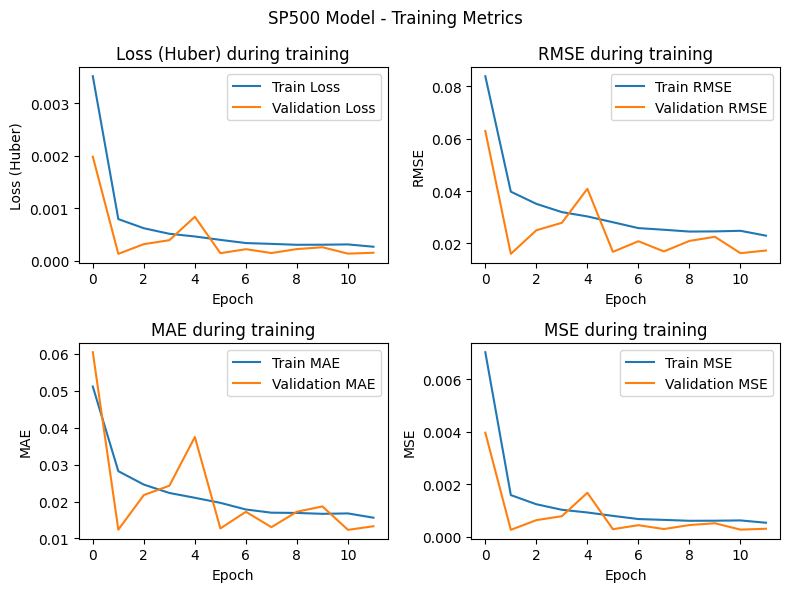

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 2: 2LSTM_D32
model = keras.Sequential([
    LSTM(units=128, return_sequences=True, input_shape=(time_step, features_num)),
    Dropout(0.3),
    LSTM(units=64, return_sequences=False),
    Dropout(0.3),
    Dense(units=32),
    Dense(units=1) # Output a single predicted value
], name="2LSTM_D32")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values1[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 4s - 31ms/step - loss: 0.0043 - mae: 0.0556 - mse: 0.0086 - rmse: 0.0926 - val_loss: 0.0035 - val_mae: 0.0800 - val_mse: 0.0069 - val_rmse: 0.0832 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 10ms/step - loss: 0.0012 - mae: 0.0340 - mse: 0.0024 - rmse: 0.0492 - val_loss: 0.0034 - val_mae: 0.0798 - val_mse: 0.0068 - val_rmse: 0.0826 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 14ms/step - loss: 9.8995e-04 - mae: 0.0305 - mse: 0.0020 - rmse: 0.0445 - val_loss: 0.0049 - val_mae: 0.0963 - val_mse: 0.0098 - val_rmse: 0.0988 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 13ms/step - loss: 7.4990e-04 - mae: 0.0258 - mse: 0.0015 - rmse: 0.0387 - val_loss: 3.8571e-04 - val_mae: 0.0235 - val_mse: 7.7143e-04 - val_rmse: 0.0278 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 11ms/step - loss: 6.5239e-04 - mae: 0.0241 - mse: 0.0013 - rmse: 0.0361 - val_loss: 5.9489e-04 - val_mae: 0.0301 - val_mse: 0.0012 - val_rmse: 0.0345 - learning_rate: 5.0000e-04
Epoch 6/

{'loss': 0.000472, 'mae': 0.020385, 'mse': 0.000944, 'rmse': 0.030717, 'val_loss': 0.000734, 'val_mae': 0.033976, 'val_mse': 0.001469, 'val_rmse': 0.038323, 'learning_rate': 0.000125}


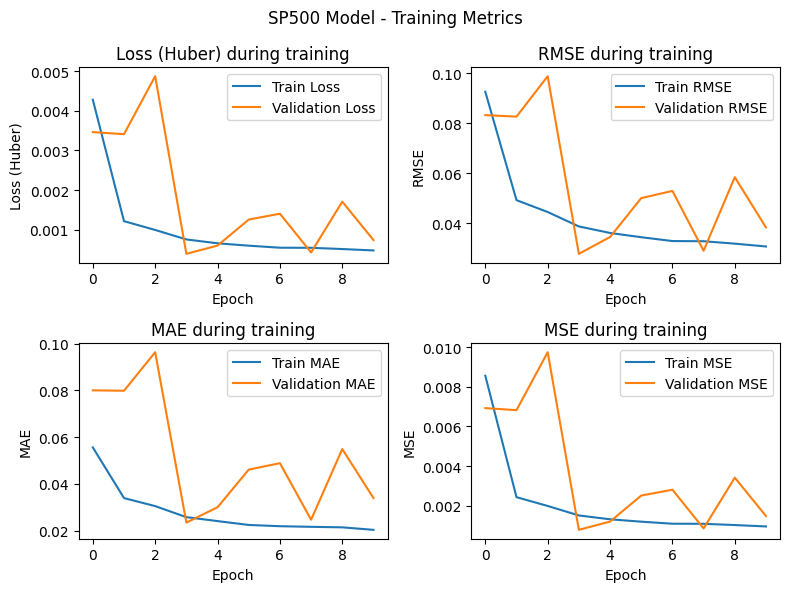

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 3: 3LSTM_D16
model = keras.Sequential([
    LSTM(units=128, return_sequences=True, input_shape=(time_step, features_num)),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="3LSTM_D16")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values1[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 6s - 47ms/step - loss: 0.0036 - mae: 0.0544 - mse: 0.0073 - rmse: 0.0853 - val_loss: 0.0026 - val_mae: 0.0660 - val_mse: 0.0051 - val_rmse: 0.0717 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 13ms/step - loss: 0.0013 - mae: 0.0345 - mse: 0.0026 - rmse: 0.0513 - val_loss: 0.0052 - val_mae: 0.0978 - val_mse: 0.0104 - val_rmse: 0.1019 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 13ms/step - loss: 0.0011 - mae: 0.0315 - mse: 0.0023 - rmse: 0.0476 - val_loss: 0.0039 - val_mae: 0.0836 - val_mse: 0.0079 - val_rmse: 0.0889 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 13ms/step - loss: 9.0422e-04 - mae: 0.0276 - mse: 0.0018 - rmse: 0.0425 - val_loss: 0.0022 - val_mae: 0.0605 - val_mse: 0.0044 - val_rmse: 0.0664 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 2s - 13ms/step - loss: 7.2808e-04 - mae: 0.0250 - mse: 0.0015 - rmse: 0.0382 - val_loss: 0.0034 - val_mae: 0.0782 - val_mse: 0.0068 - val_rmse: 0.0826 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 2s 

{'loss': 0.000538, 'mae': 0.021921, 'mse': 0.001076, 'rmse': 0.032807, 'val_loss': 0.001665, 'val_mae': 0.051866, 'val_mse': 0.003331, 'val_rmse': 0.057711, 'learning_rate': 0.000125}


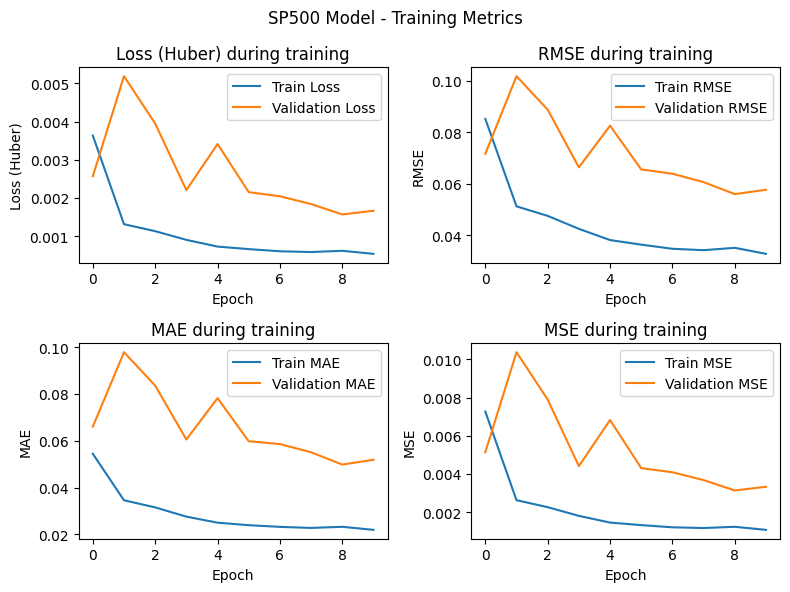

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 4: 1CNN_1LSTM_D64
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    Dense(units=64),
    Dense(units=1) # Output a single predicted value
], name="1CNN_1LSTM_D64")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values1[model.name] = history_final_values(history)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 - 4s - 33ms/step - loss: 0.0404 - mae: 0.2352 - mse: 0.0807 - rmse: 0.2841 - val_loss: 0.2354 - val_mae: 0.6822 - val_mse: 0.4707 - val_rmse: 0.6861 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 11ms/step - loss: 0.0372 - mae: 0.2291 - mse: 0.0744 - rmse: 0.2728 - val_loss: 0.2646 - val_mae: 0.7240 - val_mse: 0.5292 - val_rmse: 0.7275 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 11ms/step - loss: 0.0369 - mae: 0.2288 - mse: 0.0738 - rmse: 0.2717 - val_loss: 0.2723 - val_mae: 0.7346 - val_mse: 0.5447 - val_rmse: 0.7380 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 8ms/step - loss: 0.0367 - mae: 0.2282 - mse: 0.0733 - rmse: 0.2708 - val_loss: 0.2736 - val_mae: 0.7363 - val_mse: 0.5473 - val_rmse: 0.7398 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 8ms/step - loss: 0.0367 - mae: 0.2282 - mse: 0.0733 - rmse: 0.2708 - val_loss: 0.2745 - val_mae: 0.7375 - val_mse: 0.5490 - val_rmse: 0.7410 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s - 8ms/step - loss: 0.

{'loss': 0.036646, 'mae': 0.228104, 'mse': 0.073291, 'rmse': 0.270724, 'val_loss': 0.269164, 'val_mae': 0.730247, 'val_mse': 0.538327, 'val_rmse': 0.733708, 'learning_rate': 0.000125}


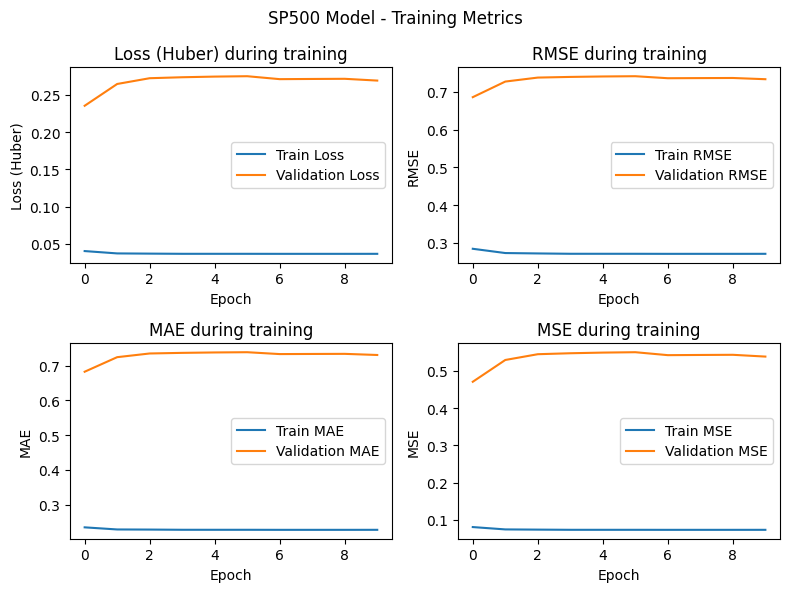

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 5: 1CNN_2LSTM_D32
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    Dense(units=32),
    Dense(units=1) # Output a single predicted value
], name="1CNN_2LSTM_D32")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values1[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 5s - 43ms/step - loss: 0.0408 - mae: 0.2358 - mse: 0.0817 - rmse: 0.2858 - val_loss: 0.2660 - val_mae: 0.7254 - val_mse: 0.5319 - val_rmse: 0.7293 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 10ms/step - loss: 0.0371 - mae: 0.2288 - mse: 0.0741 - rmse: 0.2723 - val_loss: 0.2745 - val_mae: 0.7374 - val_mse: 0.5491 - val_rmse: 0.7410 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 10ms/step - loss: 0.0369 - mae: 0.2287 - mse: 0.0737 - rmse: 0.2716 - val_loss: 0.2764 - val_mae: 0.7401 - val_mse: 0.5528 - val_rmse: 0.7435 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 10ms/step - loss: 0.0367 - mae: 0.2282 - mse: 0.0734 - rmse: 0.2709 - val_loss: 0.2756 - val_mae: 0.7390 - val_mse: 0.5512 - val_rmse: 0.7424 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 10ms/step - loss: 0.0367 - mae: 0.2282 - mse: 0.0733 - rmse: 0.2708 - val_loss: 0.2762 - val_mae: 0.7398 - val_mse: 0.5524 - val_rmse: 0.7433 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s - 10ms/s

{'loss': 0.036667, 'mae': 0.228204, 'mse': 0.073334, 'rmse': 0.270802, 'val_loss': 0.271358, 'val_mae': 0.733242, 'val_mse': 0.542717, 'val_rmse': 0.736693, 'learning_rate': 0.000125}


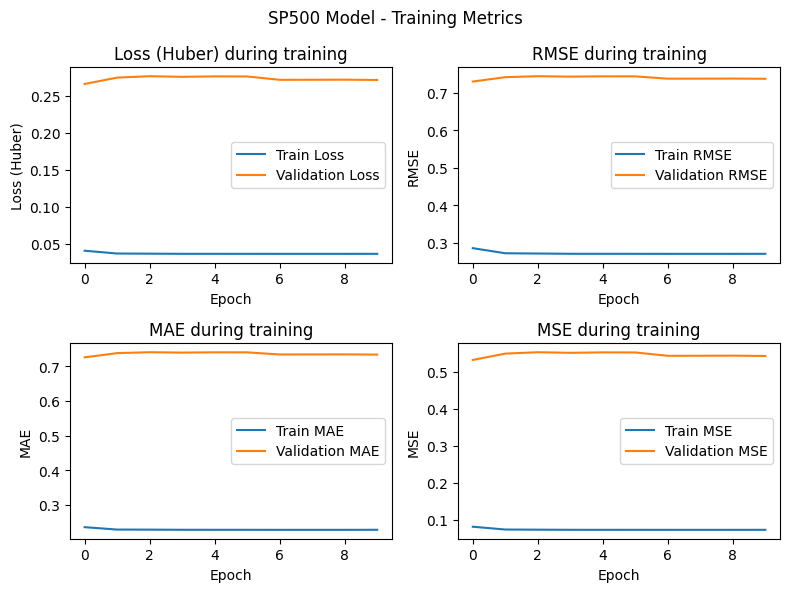

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 6: 1CNN_3LSTM_D16
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_3LSTM_D16")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values1[model.name] = history_final_values(history)


Epoch 1/50
123/123 - 5s - 41ms/step - loss: 0.0050 - mae: 0.0630 - mse: 0.0101 - rmse: 0.1005 - val_loss: 0.0021 - val_mae: 0.0586 - val_mse: 0.0042 - val_rmse: 0.0652 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 12ms/step - loss: 0.0017 - mae: 0.0411 - mse: 0.0034 - rmse: 0.0582 - val_loss: 0.0107 - val_mae: 0.1425 - val_mse: 0.0215 - val_rmse: 0.1465 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 12ms/step - loss: 0.0013 - mae: 0.0335 - mse: 0.0025 - rmse: 0.0501 - val_loss: 0.0025 - val_mae: 0.0629 - val_mse: 0.0050 - val_rmse: 0.0707 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 12ms/step - loss: 9.3494e-04 - mae: 0.0287 - mse: 0.0019 - rmse: 0.0432 - val_loss: 0.0051 - val_mae: 0.0941 - val_mse: 0.0103 - val_rmse: 0.1014 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 3s - 28ms/step - loss: 8.8576e-04 - mae: 0.0283 - mse: 0.0018 - rmse: 0.0421 - val_loss: 0.0015 - val_mae: 0.0483 - val_mse: 0.0030 - val_rmse: 0.0548 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 2s 

{'loss': 0.000665, 'mae': 0.024077, 'mse': 0.001331, 'rmse': 0.036478, 'val_loss': 0.003551, 'val_mae': 0.077268, 'val_mse': 0.007101, 'val_rmse': 0.084269, 'learning_rate': 0.000125}


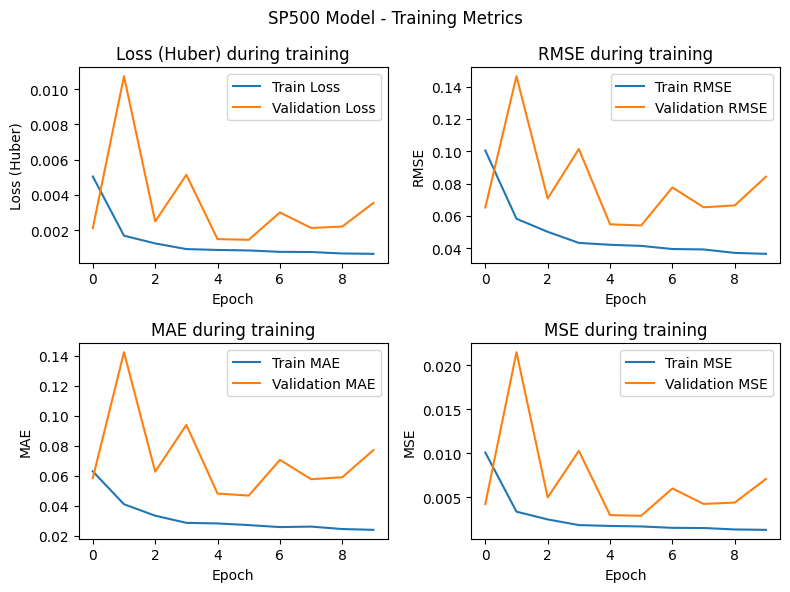

In [ ]:
print(history_final_values(history))
plot_history(history)

Display the training and validation results of solving model overfitting by using the `final_values1` dictionary.

In [ ]:
pd.DataFrame.from_dict(final_values1, orient="index")

,loss,mae,mse,rmse,val_loss,val_mae,val_mse,val_rmse,learning_rate
1LSTM_D64,0.000264,0.015627,0.000528,0.022970,0.000150,0.013310,0.000299,0.017296,0.000125
2LSTM_D32,0.000472,0.020385,0.000944,0.030717,0.000734,0.033976,0.001469,0.038323,0.000125
3LSTM_D16,0.000538,0.021921,0.001076,0.032807,0.001665,0.051866,0.003331,0.057711,0.000125
1CNN_1LSTM_D64,0.036646,0.228104,0.073291,0.270724,0.269164,0.730247,0.538327,0.733708,0.000125
1CNN_2LSTM_D32,0.036667,0.228204,0.073334,0.270802,0.271358,0.733242,0.542717,0.736693,0.000125
1CNN_3LSTM_D16,0.000665,0.024077,0.001331,0.036478,0.003551,0.077268,0.007101,0.084269,0.000125


Choose 1LSTM_D64 model and 1CNN_3LSTM_D16 model to do next step

### 9.2. 2nd Training - Parameter turning

In [ ]:
final_values2 = {} # To hold the final metric values for the 2nd training run

In [ ]:
# Model 1: 1LSTM_1u128
model = keras.Sequential([
    LSTM(units=128, return_sequences=False, input_shape=(time_step, features_num)),
    Dropout(0.3),
    Dense(units=64),
    Dense(units=1) # Output a single predicted value
], name="1LSTM_1u128")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


123/123 - 3s - 26ms/step - loss: 0.0031 - mae: 0.0480 - mse: 0.0061 - rmse: 0.0782 - val_loss: 0.0014 - val_mae: 0.0494 - val_mse: 0.0027 - val_rmse: 0.0521 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 10ms/step - loss: 7.5133e-04 - mae: 0.0275 - mse: 0.0015 - rmse: 0.0388 - val_loss: 8.9779e-04 - val_mae: 0.0394 - val_mse: 0.0018 - val_rmse: 0.0424 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 18ms/step - loss: 6.8390e-04 - mae: 0.0262 - mse: 0.0014 - rmse: 0.0370 - val_loss: 3.2442e-04 - val_mae: 0.0223 - val_mse: 6.4884e-04 - val_rmse: 0.0255 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 8ms/step - loss: 4.8455e-04 - mae: 0.0215 - mse: 9.6909e-04 - rmse: 0.0311 - val_loss: 1.6023e-04 - val_mae: 0.0136 - val_mse: 3.2046e-04 - val_rmse: 0.0179 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 8ms/step - loss: 4.3556e-04 - mae: 0.0205 - mse: 8.7111e-04 - rmse: 0.0295 - val_loss: 1.2193e-04 - val_mae: 0.0118 - val_mse: 2.4387e-04 - val_rmse: 0.0156 - learning_rate: 5.00

{'loss': 0.000273, 'mae': 0.016046, 'mse': 0.000547, 'rmse': 0.023382, 'val_loss': 0.000239, 'val_mae': 0.018131, 'val_mse': 0.000477, 'val_rmse': 0.021847, 'learning_rate': 6.3e-05}


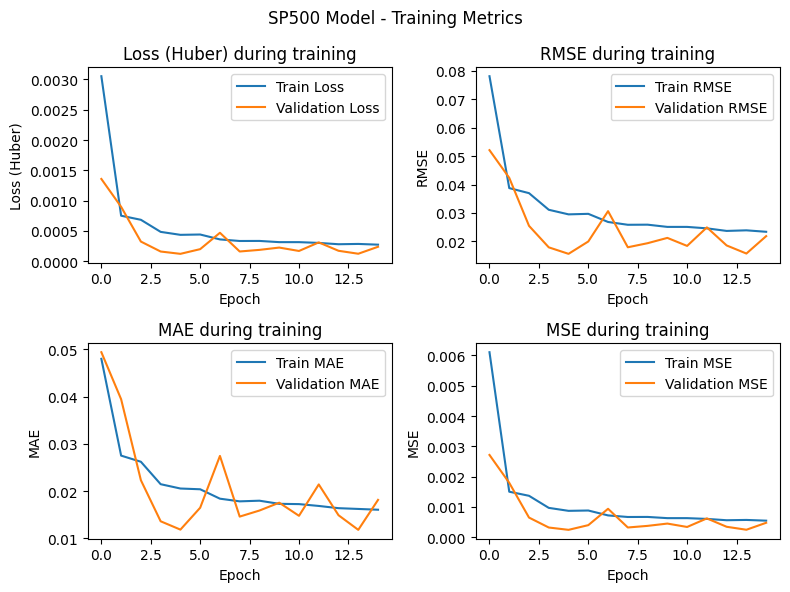

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 2: 1LSTM_1u256
model = keras.Sequential([
    LSTM(units=256, return_sequences=False, input_shape=(time_step, features_num)),
    Dropout(0.3),
    Dense(units=64),
    Dense(units=1) # Output a single predicted value
], name="1LSTM_1u256")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 3s - 23ms/step - loss: 0.0020 - mae: 0.0384 - mse: 0.0041 - rmse: 0.0639 - val_loss: 3.4622e-04 - val_mae: 0.0230 - val_mse: 6.9243e-04 - val_rmse: 0.0263 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 8ms/step - loss: 4.9008e-04 - mae: 0.0220 - mse: 9.8015e-04 - rmse: 0.0313 - val_loss: 0.0012 - val_mae: 0.0472 - val_mse: 0.0025 - val_rmse: 0.0497 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 8ms/step - loss: 4.0868e-04 - mae: 0.0202 - mse: 8.1737e-04 - rmse: 0.0286 - val_loss: 1.3257e-04 - val_mae: 0.0119 - val_mse: 2.6513e-04 - val_rmse: 0.0163 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 8ms/step - loss: 3.3596e-04 - mae: 0.0182 - mse: 6.7191e-04 - rmse: 0.0259 - val_loss: 6.5681e-04 - val_mae: 0.0334 - val_mse: 0.0013 - val_rmse: 0.0362 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 2s - 13ms/step - loss: 2.9064e-04 - mae: 0.0167 - mse: 5.8128e-04 - rmse: 0.0241 - val_loss: 1.0407e-04 - val_mae: 0.0106 - val_mse: 2.0814e-04 - val_rmse: 0.0144 - l

{'loss': 0.000168, 'mae': 0.012524, 'mse': 0.000336, 'rmse': 0.01834, 'val_loss': 0.000157, 'val_mae': 0.014355, 'val_mse': 0.000313, 'val_rmse': 0.017702, 'learning_rate': 1.6e-05}


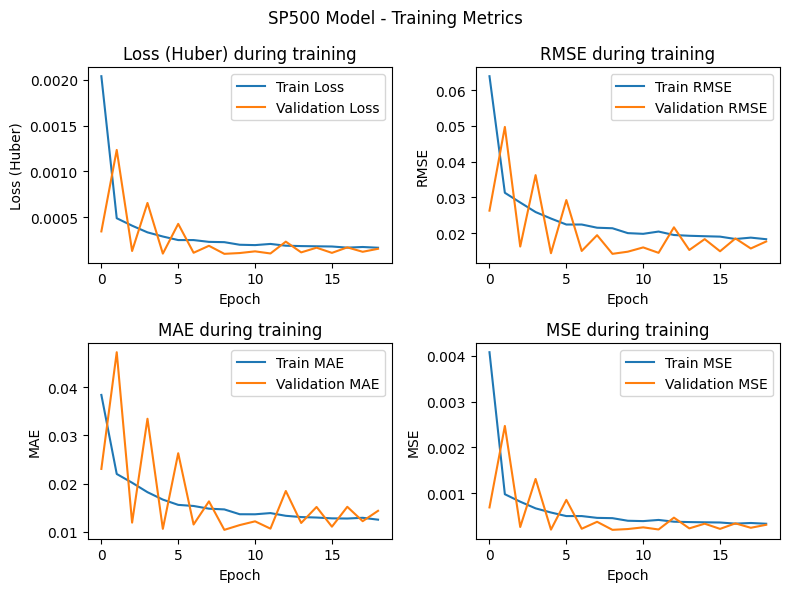

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 3: 1CNN_f64_k5_3LSTM_1u128
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_f64_k5_3LSTM_1u128")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


123/123 - 6s - 45ms/step - loss: 0.0048 - mae: 0.0646 - mse: 0.0096 - rmse: 0.0980 - val_loss: 0.0050 - val_mae: 0.0940 - val_mse: 0.0100 - val_rmse: 0.0999 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 12ms/step - loss: 0.0017 - mae: 0.0400 - mse: 0.0034 - rmse: 0.0583 - val_loss: 0.0074 - val_mae: 0.1152 - val_mse: 0.0147 - val_rmse: 0.1214 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 15ms/step - loss: 0.0011 - mae: 0.0320 - mse: 0.0023 - rmse: 0.0476 - val_loss: 0.0063 - val_mae: 0.1066 - val_mse: 0.0126 - val_rmse: 0.1120 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 15ms/step - loss: 9.0063e-04 - mae: 0.0279 - mse: 0.0018 - rmse: 0.0424 - val_loss: 0.0024 - val_mae: 0.0615 - val_mse: 0.0047 - val_rmse: 0.0687 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 12ms/step - loss: 7.5778e-04 - mae: 0.0259 - mse: 0.0015 - rmse: 0.0389 - val_loss: 0.0014 - val_mae: 0.0450 - val_mse: 0.0028 - val_rmse: 0.0531 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s - 11ms/step

{'loss': 0.000587, 'mae': 0.022834, 'mse': 0.001173, 'rmse': 0.034251, 'val_loss': 0.002215, 'val_mae': 0.059356, 'val_mse': 0.00443, 'val_rmse': 0.06656, 'learning_rate': 0.000125}


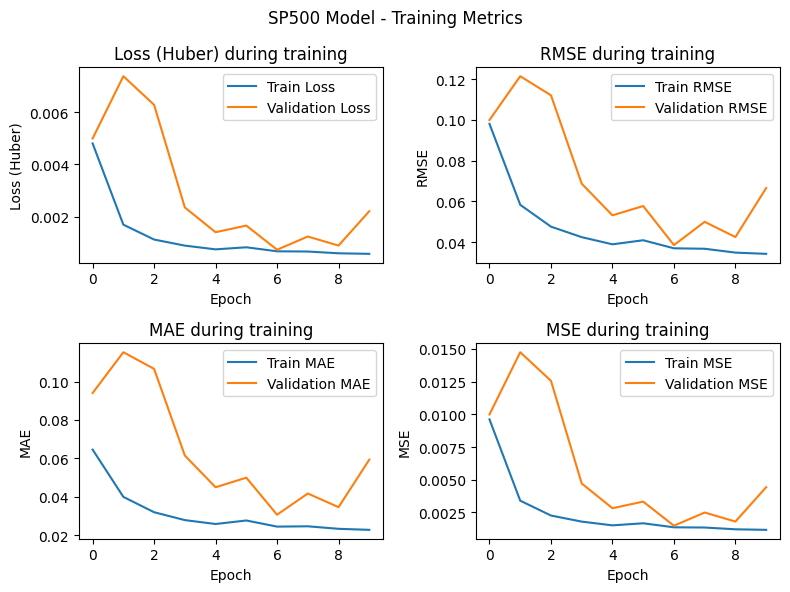

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 4: 1CNN_f64_k3_3LSTM_1u128
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_f64_k3_3LSTM_1u128")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 6s - 46ms/step - loss: 0.0038 - mae: 0.0574 - mse: 0.0077 - rmse: 0.0877 - val_loss: 0.0063 - val_mae: 0.1059 - val_mse: 0.0125 - val_rmse: 0.1118 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 12ms/step - loss: 0.0017 - mae: 0.0412 - mse: 0.0035 - rmse: 0.0590 - val_loss: 0.0146 - val_mae: 0.1669 - val_mse: 0.0292 - val_rmse: 0.1708 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 12ms/step - loss: 0.0011 - mae: 0.0321 - mse: 0.0023 - rmse: 0.0476 - val_loss: 0.0033 - val_mae: 0.0746 - val_mse: 0.0067 - val_rmse: 0.0817 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 12ms/step - loss: 9.4212e-04 - mae: 0.0292 - mse: 0.0019 - rmse: 0.0434 - val_loss: 0.0026 - val_mae: 0.0644 - val_mse: 0.0052 - val_rmse: 0.0719 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 11ms/step - loss: 8.7195e-04 - mae: 0.0277 - mse: 0.0017 - rmse: 0.0418 - val_loss: 0.0040 - val_mae: 0.0843 - val_mse: 0.0081 - val_rmse: 0.0899 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 2s 

{'loss': 0.00065, 'mae': 0.024077, 'mse': 0.001299, 'rmse': 0.036047, 'val_loss': 0.002183, 'val_mae': 0.05923, 'val_mse': 0.004366, 'val_rmse': 0.066078, 'learning_rate': 0.000125}


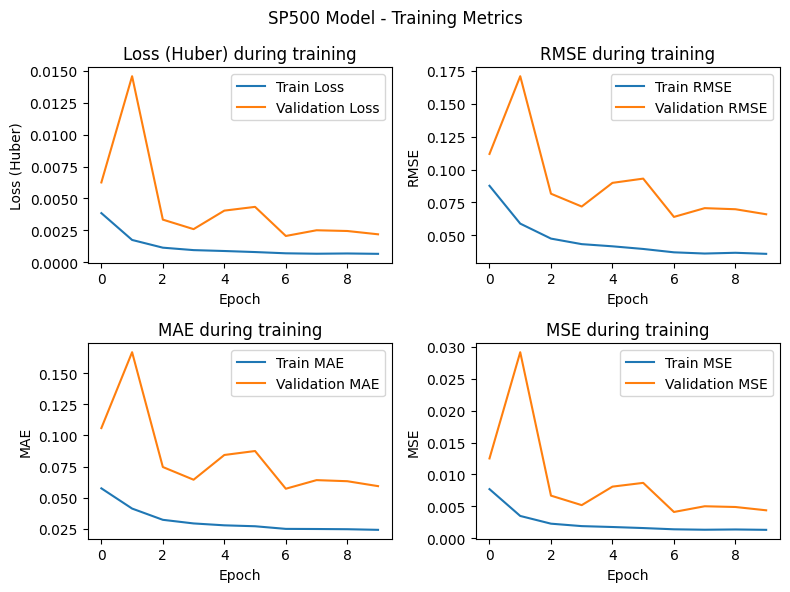

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 5: 1CNN_f64_k5_3LSTM_1u256
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=256, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_f64_k5_3LSTM_1u256")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 5s - 45ms/step - loss: 0.0041 - mae: 0.0578 - mse: 0.0081 - rmse: 0.0900 - val_loss: 0.0077 - val_mae: 0.1193 - val_mse: 0.0154 - val_rmse: 0.1243 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 14ms/step - loss: 0.0016 - mae: 0.0389 - mse: 0.0032 - rmse: 0.0566 - val_loss: 0.0076 - val_mae: 0.1182 - val_mse: 0.0153 - val_rmse: 0.1235 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 12ms/step - loss: 0.0013 - mae: 0.0343 - mse: 0.0025 - rmse: 0.0505 - val_loss: 0.0016 - val_mae: 0.0501 - val_mse: 0.0033 - val_rmse: 0.0571 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 12ms/step - loss: 9.1798e-04 - mae: 0.0287 - mse: 0.0018 - rmse: 0.0428 - val_loss: 0.0086 - val_mae: 0.1266 - val_mse: 0.0173 - val_rmse: 0.1315 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 11ms/step - loss: 8.3652e-04 - mae: 0.0273 - mse: 0.0017 - rmse: 0.0409 - val_loss: 0.0065 - val_mae: 0.1098 - val_mse: 0.0130 - val_rmse: 0.1141 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s 

{'loss': 0.000554, 'mae': 0.021929, 'mse': 0.001109, 'rmse': 0.0333, 'val_loss': 0.002088, 'val_mae': 0.057895, 'val_mse': 0.004176, 'val_rmse': 0.064623, 'learning_rate': 0.000125}


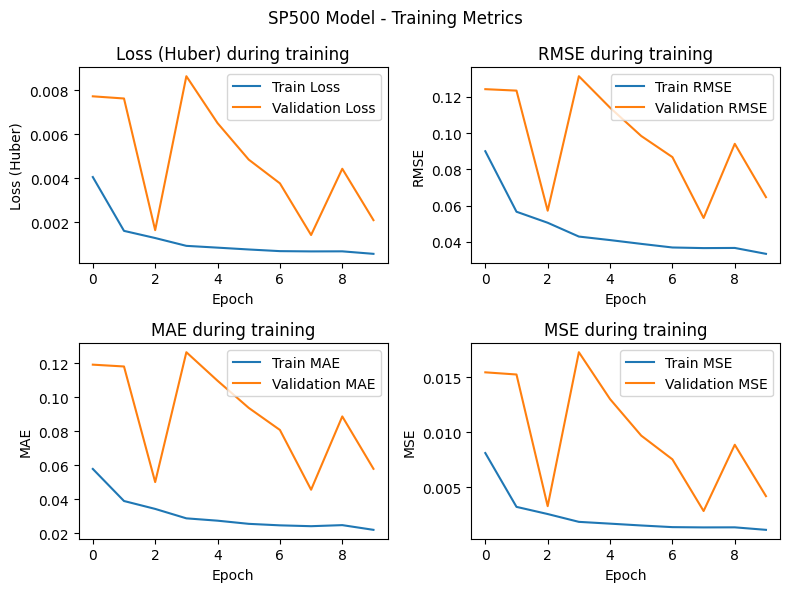

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 6: 1CNN_f128_k5_3LSTM_1u128
model = Sequential([
    Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_f128_k5_3LSTM_1u128")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 5s - 40ms/step - loss: 0.0042 - mae: 0.0595 - mse: 0.0084 - rmse: 0.0914 - val_loss: 0.0035 - val_mae: 0.0757 - val_mse: 0.0069 - val_rmse: 0.0831 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 12ms/step - loss: 0.0015 - mae: 0.0380 - mse: 0.0031 - rmse: 0.0556 - val_loss: 0.0043 - val_mae: 0.0853 - val_mse: 0.0085 - val_rmse: 0.0923 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 12ms/step - loss: 0.0013 - mae: 0.0339 - mse: 0.0026 - rmse: 0.0514 - val_loss: 0.0095 - val_mae: 0.1338 - val_mse: 0.0191 - val_rmse: 0.1381 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 13ms/step - loss: 9.7470e-04 - mae: 0.0296 - mse: 0.0019 - rmse: 0.0442 - val_loss: 0.0015 - val_mae: 0.0475 - val_mse: 0.0029 - val_rmse: 0.0540 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 2s - 16ms/step - loss: 9.6620e-04 - mae: 0.0291 - mse: 0.0019 - rmse: 0.0440 - val_loss: 0.0058 - val_mae: 0.1028 - val_mse: 0.0116 - val_rmse: 0.1078 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s 

{'loss': 0.00064, 'mae': 0.023235, 'mse': 0.001281, 'rmse': 0.035789, 'val_loss': 0.001813, 'val_mae': 0.05308, 'val_mse': 0.003625, 'val_rmse': 0.060209, 'learning_rate': 0.000125}


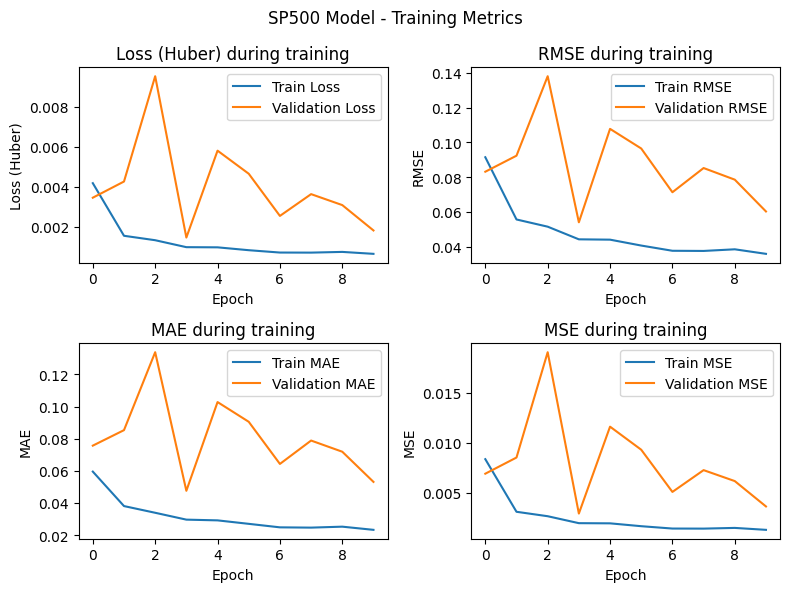

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 7: 1CNN_f128_k3_3LSTM_1u128
model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_f128_k3_3LSTM_1u128")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 6s - 47ms/step - loss: 0.0048 - mae: 0.0616 - mse: 0.0096 - rmse: 0.0978 - val_loss: 0.0030 - val_mae: 0.0701 - val_mse: 0.0060 - val_rmse: 0.0772 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 12ms/step - loss: 0.0015 - mae: 0.0373 - mse: 0.0031 - rmse: 0.0556 - val_loss: 0.0053 - val_mae: 0.0968 - val_mse: 0.0106 - val_rmse: 0.1032 - learning_rate: 0.0010
Epoch 3/50
123/123 - 1s - 12ms/step - loss: 0.0013 - mae: 0.0350 - mse: 0.0026 - rmse: 0.0509 - val_loss: 0.0038 - val_mae: 0.0802 - val_mse: 0.0076 - val_rmse: 0.0874 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 12ms/step - loss: 0.0010 - mae: 0.0294 - mse: 0.0020 - rmse: 0.0450 - val_loss: 0.0047 - val_mae: 0.0907 - val_mse: 0.0095 - val_rmse: 0.0975 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 12ms/step - loss: 8.8036e-04 - mae: 0.0276 - mse: 0.0018 - rmse: 0.0420 - val_loss: 0.0031 - val_mae: 0.0720 - val_mse: 0.0063 - val_rmse: 0.0791 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s - 12

{'loss': 0.000642, 'mae': 0.0235, 'mse': 0.001285, 'rmse': 0.035842, 'val_loss': 0.003833, 'val_mae': 0.081183, 'val_mse': 0.007666, 'val_rmse': 0.087558, 'learning_rate': 0.000125}


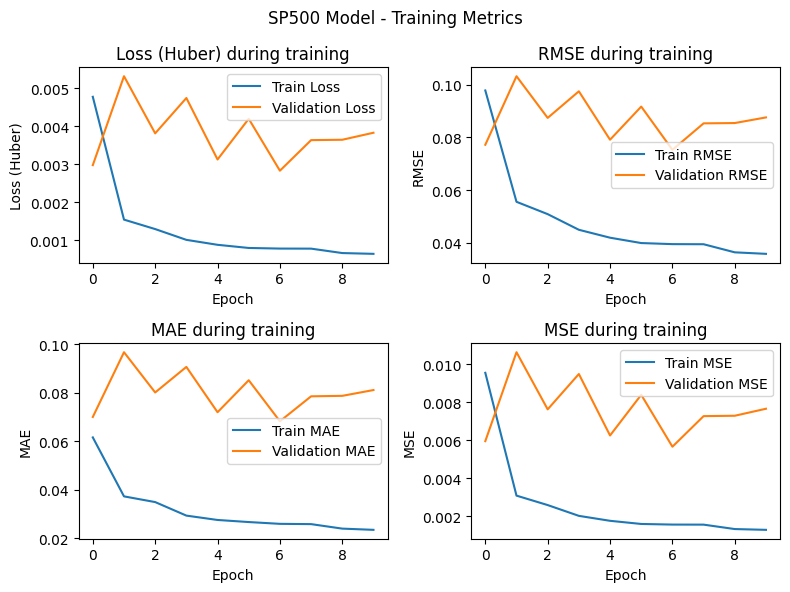

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 8: 1CNN_f128_k5_3LSTM_1u256
model = Sequential([
    Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=256, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_f128_k5_3LSTM_1u256")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values2[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 5s - 42ms/step - loss: 0.0047 - mae: 0.0630 - mse: 0.0093 - rmse: 0.0966 - val_loss: 5.4085e-04 - val_mae: 0.0249 - val_mse: 0.0011 - val_rmse: 0.0329 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 14ms/step - loss: 0.0016 - mae: 0.0378 - mse: 0.0032 - rmse: 0.0561 - val_loss: 0.0056 - val_mae: 0.1005 - val_mse: 0.0111 - val_rmse: 0.1056 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 19ms/step - loss: 0.0014 - mae: 0.0358 - mse: 0.0028 - rmse: 0.0527 - val_loss: 0.0035 - val_mae: 0.0787 - val_mse: 0.0071 - val_rmse: 0.0843 - learning_rate: 0.0010
Epoch 4/50
123/123 - 1s - 12ms/step - loss: 9.5758e-04 - mae: 0.0293 - mse: 0.0019 - rmse: 0.0438 - val_loss: 0.0031 - val_mae: 0.0726 - val_mse: 0.0062 - val_rmse: 0.0786 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 12ms/step - loss: 8.9226e-04 - mae: 0.0281 - mse: 0.0018 - rmse: 0.0422 - val_loss: 0.0054 - val_mae: 0.0994 - val_mse: 0.0109 - val_rmse: 0.1044 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 -

{'loss': 0.000607, 'mae': 0.023141, 'mse': 0.001215, 'rmse': 0.034857, 'val_loss': 0.002599, 'val_mae': 0.065667, 'val_mse': 0.005198, 'val_rmse': 0.072098, 'learning_rate': 0.000125}


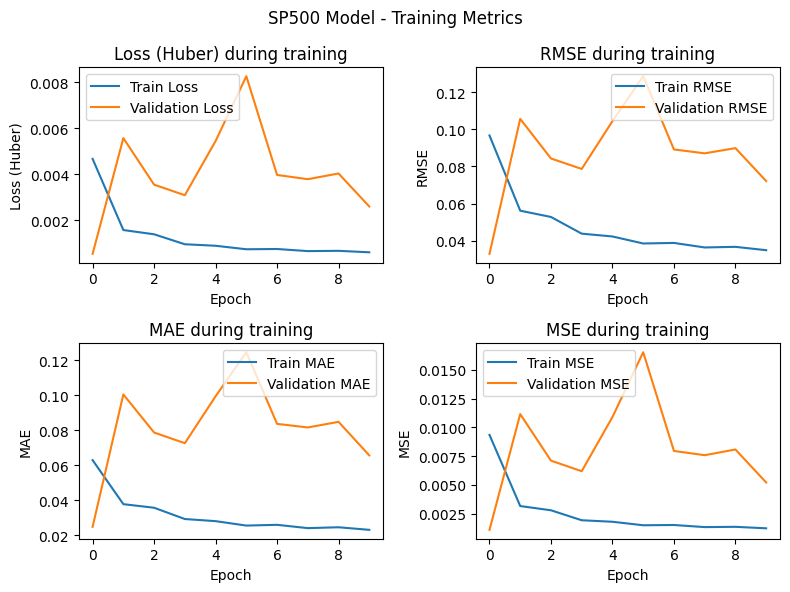

In [ ]:
print(history_final_values(history))
plot_history(history)

Display the training and validation results of solving model overfitting by using the `final_values2` dictionary.

In [ ]:
pd.DataFrame.from_dict(final_values2, orient="index")

,loss,mae,mse,rmse,val_loss,val_mae,val_mse,val_rmse,learning_rate
1LSTM_1u128,0.000273,0.016046,0.000547,0.023382,0.000239,0.018131,0.000477,0.021847,0.000063
1LSTM_1u256,0.000168,0.012524,0.000336,0.018340,0.000157,0.014355,0.000313,0.017702,0.000016
1CNN_f64_k5_3LSTM_1u128,0.000587,0.022834,0.001173,0.034251,0.002215,0.059356,0.004430,0.066560,0.000125
1CNN_f64_k3_3LSTM_1u128,0.000650,0.024077,0.001299,0.036047,0.002183,0.059230,0.004366,0.066078,0.000125
1CNN_f64_k5_3LSTM_1u256,0.000554,0.021929,0.001109,0.033300,0.002088,0.057895,0.004176,0.064623,0.000125
1CNN_f128_k5_3LSTM_1u128,0.000640,0.023235,0.001281,0.035789,0.001813,0.053080,0.003625,0.060209,0.000125
1CNN_f128_k3_3LSTM_1u128,0.000642,0.023500,0.001285,0.035842,0.003833,0.081183,0.007666,0.087558,0.000125
1CNN_f128_k5_3LSTM_1u256,0.000607,0.023141,0.001215,0.034857,0.002599,0.065667,0.005198,0.072098,0.000125


Choose 1CNN_f64_k5_3LSTM_1u256 model to do next step

### 9.3. 3rd Training - Reducing Overfitting

In [ ]:
final_values3 = {} # To hold the final metric values for the 3rd training run

In [ ]:
# Model 1: 1CNN_3BDT3LSTM
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="1CNN_3BDT3LSTM")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values3[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
123/123 - 11s - 91ms/step - loss: 0.0029 - mae: 0.0485 - mse: 0.0058 - rmse: 0.0764 - val_loss: 5.3849e-04 - val_mae: 0.0284 - val_mse: 0.0011 - val_rmse: 0.0328 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 17ms/step - loss: 0.0011 - mae: 0.0313 - mse: 0.0021 - rmse: 0.0463 - val_loss: 0.0040 - val_mae: 0.0840 - val_mse: 0.0080 - val_rmse: 0.0896 - learning_rate: 0.0010
Epoch 3/50
123/123 - 3s - 23ms/step - loss: 8.2381e-04 - mae: 0.0288 - mse: 0.0016 - rmse: 0.0406 - val_loss: 3.4768e-04 - val_mae: 0.0214 - val_mse: 6.9536e-04 - val_rmse: 0.0264 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 17ms/step - loss: 8.8063e-04 - mae: 0.0291 - mse: 0.0018 - rmse: 0.0420 - val_loss: 9.1308e-04 - val_mae: 0.0364 - val_mse: 0.0018 - val_rmse: 0.0427 - learning_rate: 0.0010
Epoch 5/50
123/123 - 2s - 17ms/step - loss: 5.6800e-04 - mae: 0.0230 - mse: 0.0011 - rmse: 0.0337 - val_loss: 0.0019 - val_mae: 0.0555 - val_mse: 0.0038 - val_rmse: 0.0619 - learning_rate: 0.0010
Epoch 6/50


{'loss': 0.000263, 'mae': 0.015625, 'mse': 0.000526, 'rmse': 0.022931, 'val_loss': 0.000193, 'val_mae': 0.015615, 'val_mse': 0.000386, 'val_rmse': 0.019647, 'learning_rate': 0.000125}


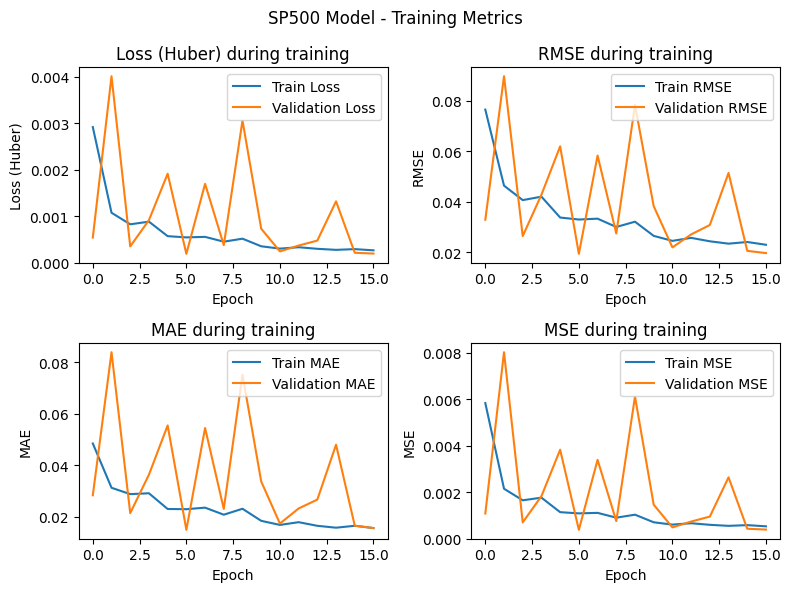

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 2: 1CNN_3LSTM_2BN
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    LSTM(units=256, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16),
    BatchNormalization(),
    Dense(units=1)
], name="1CNN_3LSTM_2BN")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values3[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 8s - 65ms/step - loss: 0.0927 - mae: 0.2955 - mse: 0.2131 - rmse: 0.4617 - val_loss: 0.2118 - val_mae: 0.6475 - val_mse: 0.4236 - val_rmse: 0.6509 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 13ms/step - loss: 0.0089 - mae: 0.1043 - mse: 0.0179 - rmse: 0.1336 - val_loss: 0.1373 - val_mae: 0.5201 - val_mse: 0.2745 - val_rmse: 0.5239 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 13ms/step - loss: 0.0052 - mae: 0.0799 - mse: 0.0104 - rmse: 0.1019 - val_loss: 0.0674 - val_mae: 0.3641 - val_mse: 0.1348 - val_rmse: 0.3672 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 13ms/step - loss: 0.0045 - mae: 0.0750 - mse: 0.0090 - rmse: 0.0949 - val_loss: 0.0334 - val_mae: 0.2527 - val_mse: 0.0668 - val_rmse: 0.2585 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 2s - 12ms/step - loss: 0.0042 - mae: 0.0720 - mse: 0.0084 - rmse: 0.0918 - val_loss: 0.0240 - val_mae: 0.2104 - val_mse: 0.0480 - val_rmse: 0.2190 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 2s - 15ms/s

{'loss': 0.003294, 'mae': 0.064657, 'mse': 0.006588, 'rmse': 0.081169, 'val_loss': 0.01805, 'val_mae': 0.177725, 'val_mse': 0.036099, 'val_rmse': 0.189998, 'learning_rate': 0.000125}


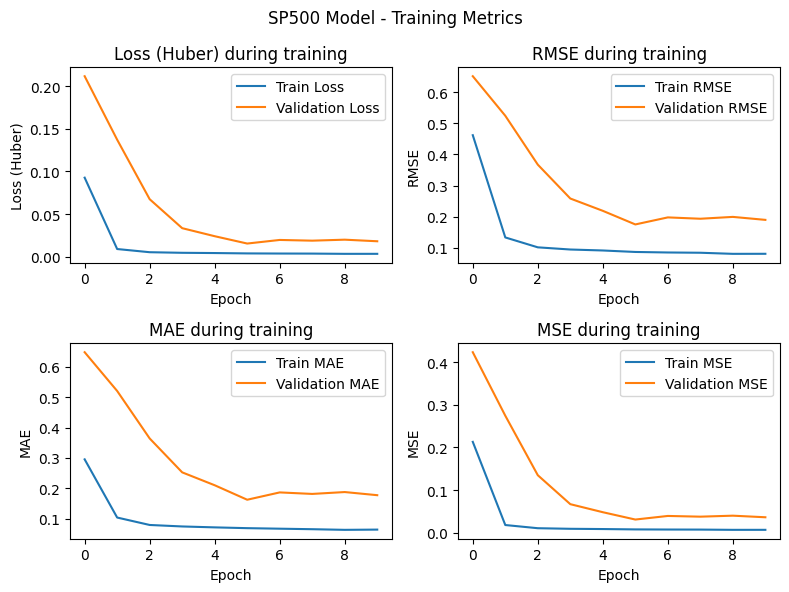

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 3: 1CNN_s2_3LSTM_rd1_1D_l2
model = Sequential([
    Conv1D(filters=64, kernel_size=5, strides=2, activation='relu', input_shape=(time_step, features_num)),
    LSTM(units=256, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False, recurrent_dropout=0.1),
    Dropout(0.2),
    Dense(units=16, kernel_regularizer=l2(0.001)),
    Dense(units=1)
], name="1CNN_s2_3LSTM_rd1_1D_l2")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values3[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 38s - 305ms/step - loss: 0.0220 - mae: 0.0632 - mse: 0.0092 - rmse: 0.0961 - val_loss: 0.0159 - val_mae: 0.0613 - val_mse: 0.0047 - val_rmse: 0.0685 - learning_rate: 0.0010
Epoch 2/50
123/123 - 28s - 224ms/step - loss: 0.0127 - mae: 0.0452 - mse: 0.0042 - rmse: 0.0651 - val_loss: 0.0192 - val_mae: 0.1440 - val_mse: 0.0221 - val_rmse: 0.1488 - learning_rate: 0.0010
Epoch 3/50
123/123 - 41s - 337ms/step - loss: 0.0078 - mae: 0.0337 - mse: 0.0026 - rmse: 0.0510 - val_loss: 0.0092 - val_mae: 0.0827 - val_mse: 0.0084 - val_rmse: 0.0918 - learning_rate: 0.0010
Epoch 4/50
123/123 - 27s - 223ms/step - loss: 0.0054 - mae: 0.0293 - mse: 0.0020 - rmse: 0.0447 - val_loss: 0.0090 - val_mae: 0.0926 - val_mse: 0.0101 - val_rmse: 0.1007 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 28s - 224ms/step - loss: 0.0044 - mae: 0.0286 - mse: 0.0019 - rmse: 0.0432 - val_loss: 0.0066 - val_mae: 0.0769 - val_mse: 0.0071 - val_rmse: 0.0845 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 2

{'loss': 0.00218, 'mae': 0.024741, 'mse': 0.001381, 'rmse': 0.037162, 'val_loss': 0.009242, 'val_mae': 0.11792, 'val_mse': 0.015615, 'val_rmse': 0.124961, 'learning_rate': 0.000125}


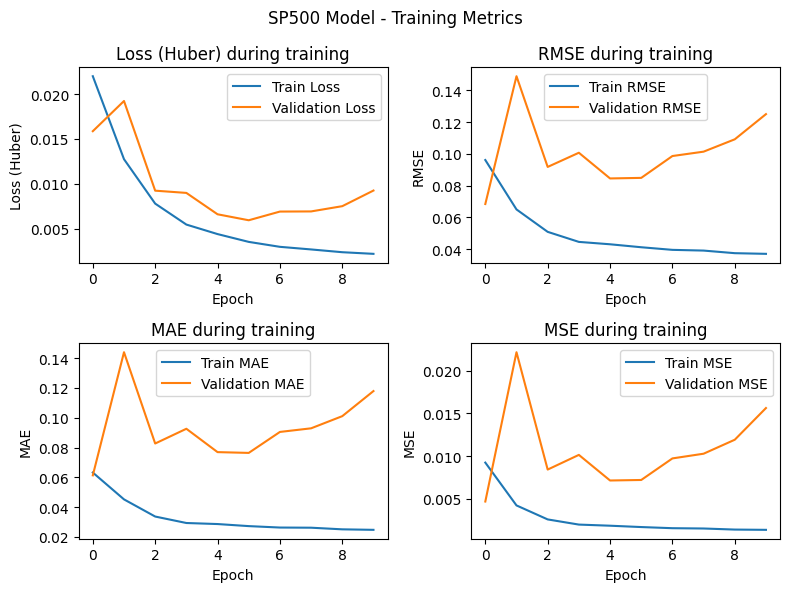

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 4: 1CNN_s2_3LSTM_rd1_1D_l1
model = Sequential([
    Conv1D(filters=64, kernel_size=5, strides=2, activation='relu', input_shape=(time_step, features_num)),
    LSTM(units=256, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.3),
    LSTM(units=64, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.3),
    LSTM(units=32, return_sequences=False, recurrent_dropout=0.1),
    Dropout(0.2),
    Dense(units=16, kernel_regularizer=l1(0.001)),
    Dense(units=1)
], name="1CNN_s2_3LSTM_rd1_1D_l1")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values3[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 36s - 295ms/step - loss: 0.0765 - mae: 0.0615 - mse: 0.0090 - rmse: 0.0946 - val_loss: 0.0617 - val_mae: 0.1207 - val_mse: 0.0159 - val_rmse: 0.1260 - learning_rate: 0.0010
Epoch 2/50
123/123 - 29s - 237ms/step - loss: 0.0409 - mae: 0.0411 - mse: 0.0037 - rmse: 0.0610 - val_loss: 0.0309 - val_mae: 0.0890 - val_mse: 0.0096 - val_rmse: 0.0979 - learning_rate: 0.0010
Epoch 3/50
123/123 - 27s - 223ms/step - loss: 0.0191 - mae: 0.0357 - mse: 0.0029 - rmse: 0.0540 - val_loss: 0.0287 - val_mae: 0.1801 - val_mse: 0.0354 - val_rmse: 0.1882 - learning_rate: 0.0010
Epoch 4/50
123/123 - 28s - 225ms/step - loss: 0.0102 - mae: 0.0340 - mse: 0.0026 - rmse: 0.0509 - val_loss: 0.0301 - val_mae: 0.2064 - val_mse: 0.0460 - val_rmse: 0.2145 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 41s - 331ms/step - loss: 0.0069 - mae: 0.0323 - mse: 0.0024 - rmse: 0.0485 - val_loss: 0.0268 - val_mae: 0.2019 - val_mse: 0.0443 - val_rmse: 0.2106 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 2

{'loss': 0.002621, 'mae': 0.029227, 'mse': 0.001822, 'rmse': 0.042686, 'val_loss': 0.037626, 'val_mae': 0.259154, 'val_mse': 0.071993, 'val_rmse': 0.268315, 'learning_rate': 0.000125}


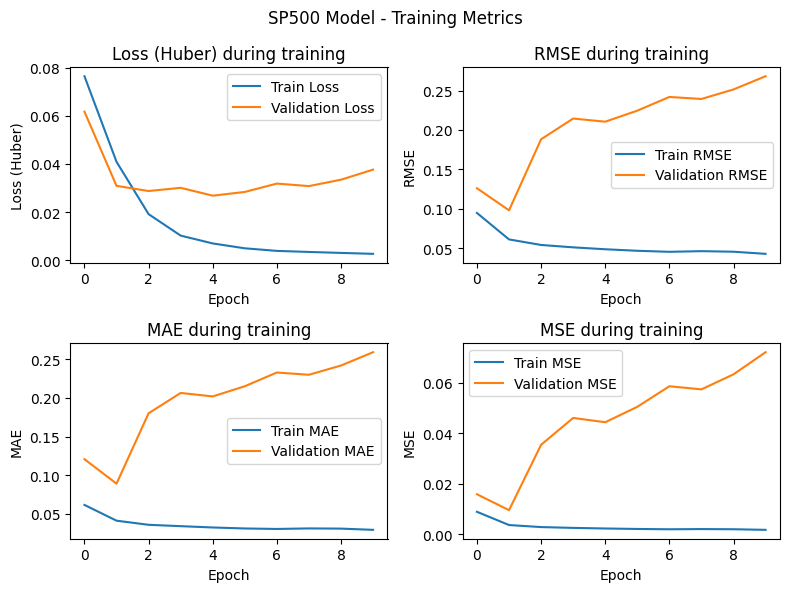

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 5: 1CNN_3LSTM_3DO3
model = Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2), # Compress the time dimension and retain the most salient features
    LSTM(units=256, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64, return_sequences=True),
    Dropout(0.5),
    LSTM(units=32, return_sequences=False),
    Dropout(0.3),
    Dense(units=16),
    Dense(units=1) # Output a single predicted value
], name="1CNN_3LSTM_3DO3")

history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values3[model.name] = history_final_values(history)

Epoch 1/50
123/123 - 5s - 42ms/step - loss: 0.0055 - mae: 0.0694 - mse: 0.0111 - rmse: 0.1053 - val_loss: 0.0090 - val_mae: 0.1292 - val_mse: 0.0179 - val_rmse: 0.1340 - learning_rate: 0.0010
Epoch 2/50
123/123 - 1s - 12ms/step - loss: 0.0025 - mae: 0.0476 - mse: 0.0049 - rmse: 0.0703 - val_loss: 0.0030 - val_mae: 0.0693 - val_mse: 0.0060 - val_rmse: 0.0773 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 16ms/step - loss: 0.0016 - mae: 0.0379 - mse: 0.0032 - rmse: 0.0564 - val_loss: 0.0018 - val_mae: 0.0528 - val_mse: 0.0036 - val_rmse: 0.0603 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 17ms/step - loss: 0.0011 - mae: 0.0312 - mse: 0.0022 - rmse: 0.0474 - val_loss: 0.0028 - val_mae: 0.0685 - val_mse: 0.0056 - val_rmse: 0.0746 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 1s - 11ms/step - loss: 0.0011 - mae: 0.0318 - mse: 0.0022 - rmse: 0.0474 - val_loss: 0.0028 - val_mae: 0.0676 - val_mse: 0.0057 - val_rmse: 0.0752 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 1s - 11ms/s

{'loss': 0.000839, 'mae': 0.027519, 'mse': 0.001678, 'rmse': 0.040958, 'val_loss': 0.002055, 'val_mae': 0.057702, 'val_mse': 0.00411, 'val_rmse': 0.064109, 'learning_rate': 0.000125}


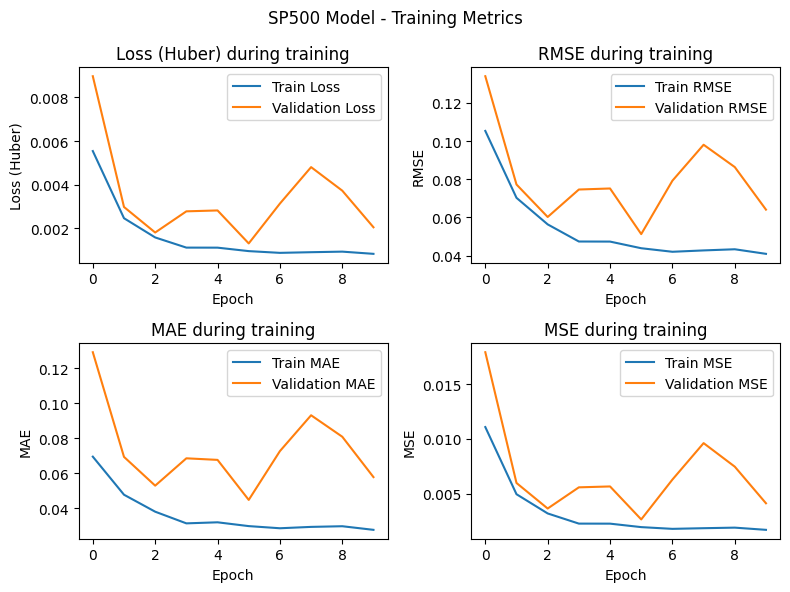

In [ ]:
print(history_final_values(history))
plot_history(history)

Display the training and validation results of solving model overfitting by using the `final_values3` dictionary.

In [ ]:
pd.DataFrame.from_dict(final_values3, orient="index")

,loss,mae,mse,rmse,val_loss,val_mae,val_mse,val_rmse,learning_rate
1CNN_3BDT3LSTM,0.000263,0.015625,0.000526,0.022931,0.000193,0.015615,0.000386,0.019647,0.000125
1CNN_3LSTM_2BN,0.003294,0.064657,0.006588,0.081169,0.018050,0.177725,0.036099,0.189998,0.000125
1CNN_s2_3LSTM_rd1_1D_l2,0.002180,0.024741,0.001381,0.037162,0.009242,0.117920,0.015615,0.124961,0.000125
1CNN_s2_3LSTM_rd1_1D_l1,0.002621,0.029227,0.001822,0.042686,0.037626,0.259154,0.071993,0.268315,0.000125
1CNN_3LSTM_3DO3,0.000839,0.027519,0.001678,0.040958,0.002055,0.057702,0.004110,0.064109,0.000125


Choose 1CNN_3BDT3LSTM model to do next step

### 9.4. 4th Training - Feature selection

In [ ]:
final_values4 = {} # To hold the final metric values for the 4th training run

In [ ]:
# Model 1: CNNLSTM_ts60_3f_sma50_rsi14

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 3 # features: Close + RSI + SMA
time_step = 60
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
sma50 = talib.SMA(close, timeperiod=50)
rsi14 = talib.RSI(close, timeperiod=14)
full = df_[['Close']].copy()
full['SMA50'] = sma50
full['RSI14'] = rsi14
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','RSI14','SMA50']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','RSI14','SMA50']].copy()
df_features['Test'] = full.loc['2025':, ['Close','RSI14','SMA50']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts60_3f_sma50_rsi14")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
123/123 - 21s - 167ms/step - loss: 0.0029 - mae: 0.0485 - mse: 0.0058 - rmse: 0.0764 - val_loss: 5.3849e-04 - val_mae: 0.0284 - val_mse: 0.0011 - val_rmse: 0.0328 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 17ms/step - loss: 0.0011 - mae: 0.0313 - mse: 0.0021 - rmse: 0.0463 - val_loss: 0.0040 - val_mae: 0.0840 - val_mse: 0.0080 - val_rmse: 0.0896 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 17ms/step - loss: 8.2378e-04 - mae: 0.0288 - mse: 0.0016 - rmse: 0.0406 - val_loss: 3.4776e-04 - val_mae: 0.0214 - val_mse: 6.9553e-04 - val_rmse: 0.0264 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 17ms/step - loss: 8.8037e-04 - mae: 0.0291 - mse: 0.0018 - rmse: 0.0420 - val_loss: 9.0295e-04 - val_mae: 0.0361 - val_mse: 0.0018 - val_rmse: 0.0425 - learning_rate: 0.0010
Epoch 5/50
123/123 - 3s - 22ms/step - loss: 5.6687e-04 - mae: 0.0230 - mse: 0.0011 - rmse: 0.0337 - val_loss: 0.0019 - val_mae: 0.0545 - val_mse: 0.0037 - val_rmse: 0.0609 - learning_rate: 0.0010
Epoch 6/50

{'loss': 0.000263, 'mae': 0.01562, 'mse': 0.000526, 'rmse': 0.022928, 'val_loss': 0.000195, 'val_mae': 0.015726, 'val_mse': 0.000391, 'val_rmse': 0.019768, 'learning_rate': 0.000125}


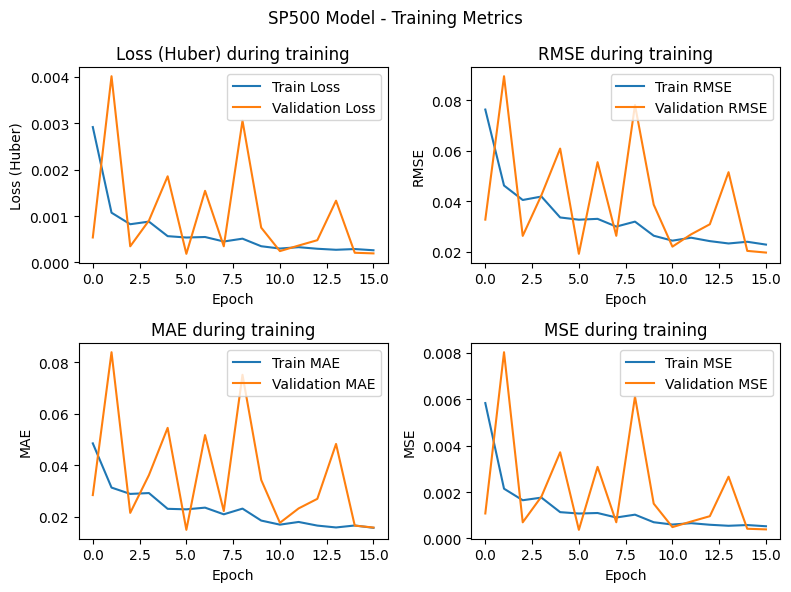

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 2: CNNLSTM_ts120_3f_sma50_rsi14

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 3 # features: Close + RSI + SMA
time_step = 120
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
sma50 = talib.SMA(close, timeperiod=50)
rsi14 = talib.RSI(close, timeperiod=14)
full = df_[['Close']].copy()
full['SMA50'] = sma50
full['RSI14'] = rsi14
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','RSI14','SMA50']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','RSI14','SMA50']].copy()
df_features['Test'] = full.loc['2025':, ['Close','RSI14','SMA50']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts120_3f_sma50_rsi14")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
121/121 - 9s - 75ms/step - loss: 0.0037 - mae: 0.0543 - mse: 0.0075 - rmse: 0.0864 - val_loss: 0.0018 - val_mae: 0.0534 - val_mse: 0.0035 - val_rmse: 0.0595 - learning_rate: 0.0010
Epoch 2/50
121/121 - 3s - 23ms/step - loss: 0.0011 - mae: 0.0335 - mse: 0.0023 - rmse: 0.0479 - val_loss: 0.0148 - val_mae: 0.1659 - val_mse: 0.0296 - val_rmse: 0.1721 - learning_rate: 0.0010
Epoch 3/50
121/121 - 3s - 22ms/step - loss: 0.0010 - mae: 0.0320 - mse: 0.0021 - rmse: 0.0454 - val_loss: 0.0049 - val_mae: 0.0908 - val_mse: 0.0097 - val_rmse: 0.0985 - learning_rate: 0.0010
Epoch 4/50
121/121 - 3s - 22ms/step - loss: 6.5028e-04 - mae: 0.0250 - mse: 0.0013 - rmse: 0.0361 - val_loss: 0.0137 - val_mae: 0.1602 - val_mse: 0.0274 - val_rmse: 0.1657 - learning_rate: 5.0000e-04
Epoch 5/50
121/121 - 9s - 73ms/step - loss: 7.0935e-04 - mae: 0.0259 - mse: 0.0014 - rmse: 0.0377 - val_loss: 0.0053 - val_mae: 0.0944 - val_mse: 0.0107 - val_rmse: 0.1033 - learning_rate: 5.0000e-04
Epoch 6/50
121/121 - 6s 

{'loss': 0.000459, 'mae': 0.020156, 'mse': 0.000918, 'rmse': 0.030297, 'val_loss': 0.003992, 'val_mae': 0.081555, 'val_mse': 0.007985, 'val_rmse': 0.089357, 'learning_rate': 0.000125}


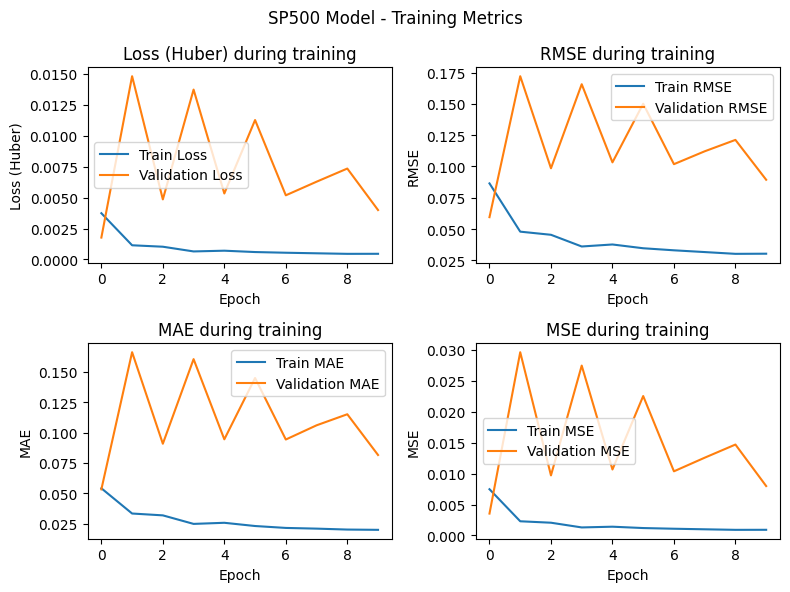

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 3: CNNLSTM_ts60_3f_sma20_rsi7

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 3 # features: Close + RSI + SMA
time_step = 60
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
sma20 = talib.SMA(close, timeperiod=20)
rsi7 = talib.RSI(close, timeperiod=7)
full = df_[['Close']].copy()
full['SMA20'] = sma20
full['RSI7'] = rsi7
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','RSI7','SMA20']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','RSI7','SMA20']].copy()
df_features['Test'] = full.loc['2025':, ['Close','RSI7','SMA20']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts60_3f_sma20_rsi7")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
124/124 - 8s - 65ms/step - loss: 0.0040 - mae: 0.0523 - mse: 0.0081 - rmse: 0.0897 - val_loss: 0.0035 - val_mae: 0.0783 - val_mse: 0.0070 - val_rmse: 0.0835 - learning_rate: 0.0010
Epoch 2/50
124/124 - 2s - 19ms/step - loss: 0.0012 - mae: 0.0328 - mse: 0.0023 - rmse: 0.0481 - val_loss: 7.3977e-04 - val_mae: 0.0317 - val_mse: 0.0015 - val_rmse: 0.0385 - learning_rate: 0.0010
Epoch 3/50
124/124 - 3s - 22ms/step - loss: 9.7046e-04 - mae: 0.0307 - mse: 0.0019 - rmse: 0.0441 - val_loss: 0.0011 - val_mae: 0.0413 - val_mse: 0.0023 - val_rmse: 0.0477 - learning_rate: 0.0010
Epoch 4/50
124/124 - 2s - 17ms/step - loss: 6.0954e-04 - mae: 0.0238 - mse: 0.0012 - rmse: 0.0349 - val_loss: 0.0033 - val_mae: 0.0764 - val_mse: 0.0066 - val_rmse: 0.0812 - learning_rate: 5.0000e-04
Epoch 5/50
124/124 - 2s - 17ms/step - loss: 5.9304e-04 - mae: 0.0228 - mse: 0.0012 - rmse: 0.0344 - val_loss: 0.0012 - val_mae: 0.0445 - val_mse: 0.0024 - val_rmse: 0.0494 - learning_rate: 5.0000e-04
Epoch 6/50
124/1

{'loss': 0.000437, 'mae': 0.019426, 'mse': 0.000874, 'rmse': 0.02956, 'val_loss': 0.000252, 'val_mae': 0.017685, 'val_mse': 0.000504, 'val_rmse': 0.022459, 'learning_rate': 0.000125}


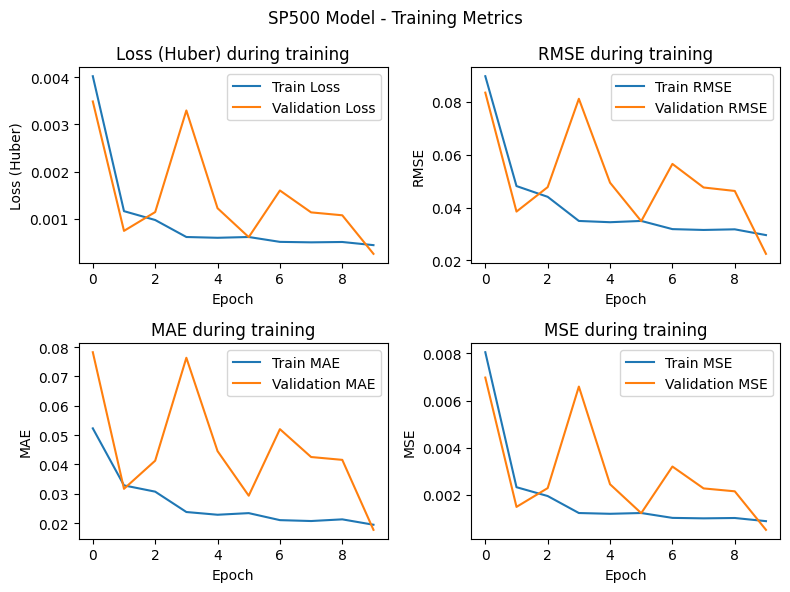

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 4: CNNLSTM_ts120_3f_sma20_rsi7

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 3 # features: Close + RSI + SMA
time_step = 120
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
sma20 = talib.SMA(close, timeperiod=20)
rsi7 = talib.RSI(close, timeperiod=7)
full = df_[['Close']].copy()
full['SMA20'] = sma20
full['RSI7'] = rsi7
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','RSI7','SMA20']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','RSI7','SMA20']].copy()
df_features['Test'] = full.loc['2025':, ['Close','RSI7','SMA20']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts120_3f_sma20_rsi7")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
122/122 - 9s - 75ms/step - loss: 0.0034 - mae: 0.0509 - mse: 0.0069 - rmse: 0.0829 - val_loss: 0.0085 - val_mae: 0.1269 - val_mse: 0.0170 - val_rmse: 0.1303 - learning_rate: 0.0010
Epoch 2/50
122/122 - 3s - 23ms/step - loss: 0.0011 - mae: 0.0329 - mse: 0.0023 - rmse: 0.0476 - val_loss: 0.0130 - val_mae: 0.1583 - val_mse: 0.0261 - val_rmse: 0.1615 - learning_rate: 0.0010
Epoch 3/50
122/122 - 3s - 28ms/step - loss: 0.0011 - mae: 0.0323 - mse: 0.0021 - rmse: 0.0460 - val_loss: 0.0052 - val_mae: 0.0972 - val_mse: 0.0104 - val_rmse: 0.1020 - learning_rate: 0.0010
Epoch 4/50
122/122 - 3s - 23ms/step - loss: 6.9311e-04 - mae: 0.0252 - mse: 0.0014 - rmse: 0.0372 - val_loss: 0.0084 - val_mae: 0.1258 - val_mse: 0.0168 - val_rmse: 0.1297 - learning_rate: 5.0000e-04
Epoch 5/50
122/122 - 4s - 33ms/step - loss: 7.1411e-04 - mae: 0.0256 - mse: 0.0014 - rmse: 0.0378 - val_loss: 0.0047 - val_mae: 0.0927 - val_mse: 0.0095 - val_rmse: 0.0972 - learning_rate: 5.0000e-04
Epoch 6/50
122/122 - 3s 

{'loss': 0.000438, 'mae': 0.019841, 'mse': 0.000876, 'rmse': 0.02959, 'val_loss': 0.001918, 'val_mae': 0.056399, 'val_mse': 0.003837, 'val_rmse': 0.061943, 'learning_rate': 0.000125}


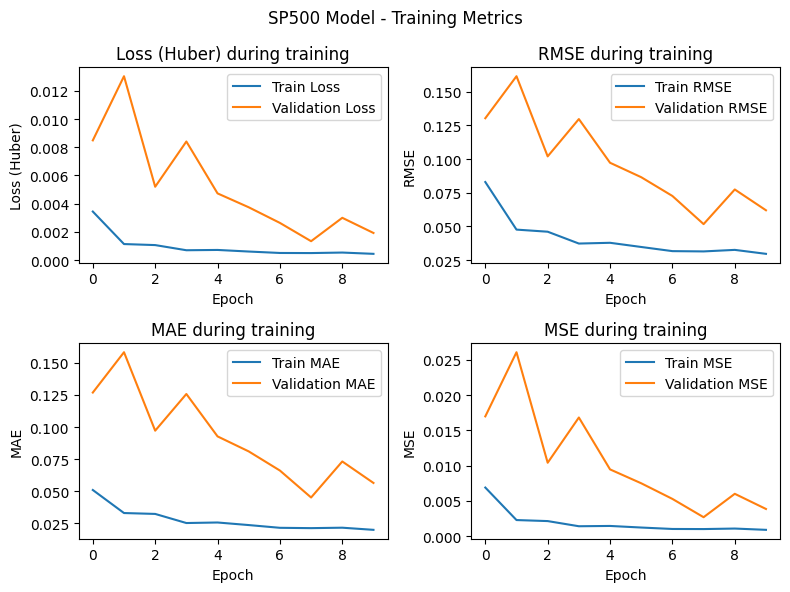

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 5: CNNLSTM_ts60_4f_macd12-26-9

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 4 # features: Close + MACD + MACDSignal + MACDHist
time_step = 60
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
full = df_[['Close']].copy()
full['MACD'] = macd
full['MACDSignal'] = macdsignal
full['MACDHist'] = macdhist
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Test'] = full.loc['2025':, ['Close','MACD','MACDSignal', 'MACDHist']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts60_4f_macd12-26-9")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
123/123 - 10s - 79ms/step - loss: 0.0084 - mae: 0.0703 - mse: 0.0169 - rmse: 0.1299 - val_loss: 0.0059 - val_mae: 0.1034 - val_mse: 0.0118 - val_rmse: 0.1086 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 17ms/step - loss: 0.0012 - mae: 0.0344 - mse: 0.0024 - rmse: 0.0494 - val_loss: 0.0058 - val_mae: 0.1031 - val_mse: 0.0116 - val_rmse: 0.1076 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 17ms/step - loss: 0.0011 - mae: 0.0331 - mse: 0.0022 - rmse: 0.0468 - val_loss: 0.0064 - val_mae: 0.1088 - val_mse: 0.0128 - val_rmse: 0.1131 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 18ms/step - loss: 8.7350e-04 - mae: 0.0293 - mse: 0.0017 - rmse: 0.0418 - val_loss: 0.0043 - val_mae: 0.0878 - val_mse: 0.0085 - val_rmse: 0.0924 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 2s - 17ms/step - loss: 7.8733e-04 - mae: 0.0274 - mse: 0.0016 - rmse: 0.0397 - val_loss: 0.0015 - val_mae: 0.0476 - val_mse: 0.0029 - val_rmse: 0.0539 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 - 3s

{'loss': 0.000513, 'mae': 0.021379, 'mse': 0.001027, 'rmse': 0.032041, 'val_loss': 0.00053, 'val_mae': 0.027327, 'val_mse': 0.001061, 'val_rmse': 0.032573, 'learning_rate': 0.000125}


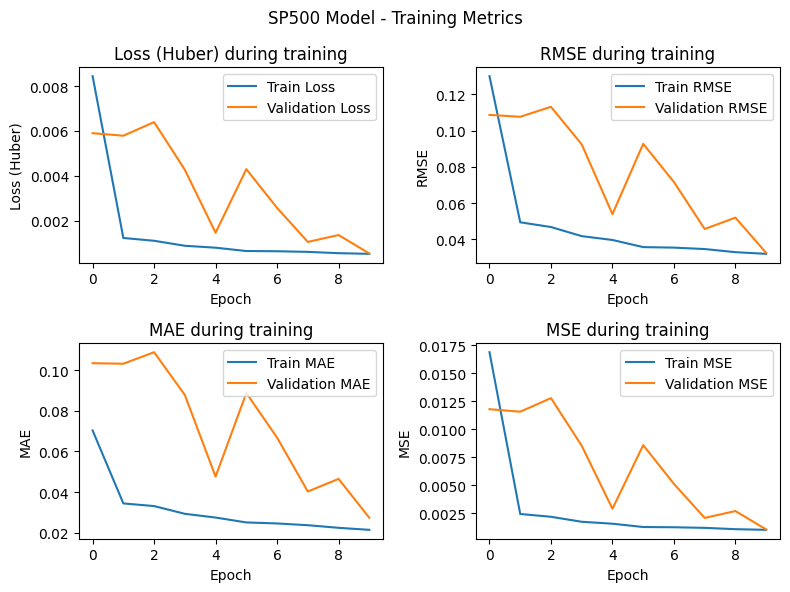

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 6: CNNLSTM_ts120_4f_macd12-26-9

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 4 # features: Close + MACD + MACDSignal + MACDHist
time_step = 120
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
full = df_[['Close']].copy()
full['MACD'] = macd
full['MACDSignal'] = macdsignal
full['MACDHist'] = macdhist
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Test'] = full.loc['2025':, ['Close','MACD','MACDSignal', 'MACDHist']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts120_4f_macd12-26-9")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
122/122 - 12s - 94ms/step - loss: 0.0063 - mae: 0.0663 - mse: 0.0127 - rmse: 0.1125 - val_loss: 0.0138 - val_mae: 0.1630 - val_mse: 0.0276 - val_rmse: 0.1663 - learning_rate: 0.0010
Epoch 2/50
122/122 - 4s - 30ms/step - loss: 0.0013 - mae: 0.0364 - mse: 0.0026 - rmse: 0.0511 - val_loss: 0.0476 - val_mae: 0.3068 - val_mse: 0.0952 - val_rmse: 0.3085 - learning_rate: 0.0010
Epoch 3/50
122/122 - 3s - 22ms/step - loss: 0.0016 - mae: 0.0400 - mse: 0.0033 - rmse: 0.0572 - val_loss: 0.0014 - val_mae: 0.0471 - val_mse: 0.0027 - val_rmse: 0.0521 - learning_rate: 0.0010
Epoch 4/50
122/122 - 3s - 22ms/step - loss: 8.4282e-04 - mae: 0.0285 - mse: 0.0017 - rmse: 0.0411 - val_loss: 0.0091 - val_mae: 0.1304 - val_mse: 0.0181 - val_rmse: 0.1346 - learning_rate: 5.0000e-04
Epoch 5/50
122/122 - 3s - 28ms/step - loss: 7.3251e-04 - mae: 0.0264 - mse: 0.0015 - rmse: 0.0383 - val_loss: 0.0034 - val_mae: 0.0763 - val_mse: 0.0069 - val_rmse: 0.0830 - learning_rate: 5.0000e-04
Epoch 6/50
122/122 - 4s

{'loss': 0.000587, 'mae': 0.023195, 'mse': 0.001175, 'rmse': 0.034275, 'val_loss': 0.004542, 'val_mae': 0.089996, 'val_mse': 0.009084, 'val_rmse': 0.09531, 'learning_rate': 0.000125}


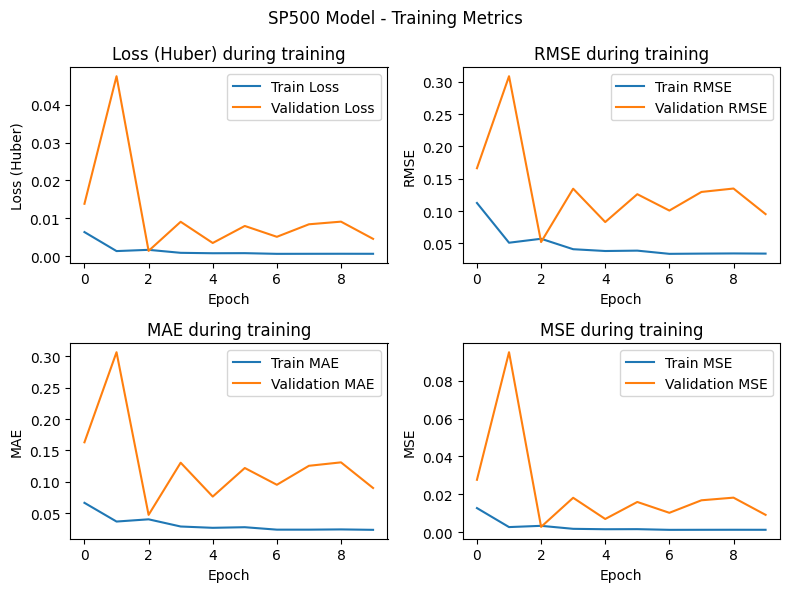

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 7: CNNLSTM_ts60_4f_macd18-39-13

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 4 # features: Close + MACD + MACDSignal + MACDHist
time_step = 60
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=18, slowperiod=39, signalperiod=13)
full = df_[['Close']].copy()
full['MACD'] = macd
full['MACDSignal'] = macdsignal
full['MACDHist'] = macdhist
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Test'] = full.loc['2025':, ['Close','MACD','MACDSignal', 'MACDHist']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts60_4f_macd18-39-13")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
123/123 - 8s - 66ms/step - loss: 0.0076 - mae: 0.0689 - mse: 0.0152 - rmse: 0.1231 - val_loss: 0.0048 - val_mae: 0.0920 - val_mse: 0.0097 - val_rmse: 0.0984 - learning_rate: 0.0010
Epoch 2/50
123/123 - 2s - 20ms/step - loss: 0.0011 - mae: 0.0331 - mse: 0.0022 - rmse: 0.0469 - val_loss: 0.0018 - val_mae: 0.0525 - val_mse: 0.0036 - val_rmse: 0.0602 - learning_rate: 0.0010
Epoch 3/50
123/123 - 2s - 18ms/step - loss: 9.6909e-04 - mae: 0.0313 - mse: 0.0019 - rmse: 0.0440 - val_loss: 0.0021 - val_mae: 0.0574 - val_mse: 0.0042 - val_rmse: 0.0652 - learning_rate: 0.0010
Epoch 4/50
123/123 - 2s - 17ms/step - loss: 8.8281e-04 - mae: 0.0289 - mse: 0.0018 - rmse: 0.0420 - val_loss: 0.0029 - val_mae: 0.0683 - val_mse: 0.0058 - val_rmse: 0.0759 - learning_rate: 5.0000e-04
Epoch 5/50
123/123 - 2s - 17ms/step - loss: 7.6366e-04 - mae: 0.0278 - mse: 0.0015 - rmse: 0.0391 - val_loss: 0.0013 - val_mae: 0.0424 - val_mse: 0.0025 - val_rmse: 0.0502 - learning_rate: 5.0000e-04
Epoch 6/50
123/123 -

{'loss': 0.000501, 'mae': 0.021315, 'mse': 0.001003, 'rmse': 0.031662, 'val_loss': 0.001109, 'val_mae': 0.038805, 'val_mse': 0.002218, 'val_rmse': 0.047092, 'learning_rate': 0.000125}


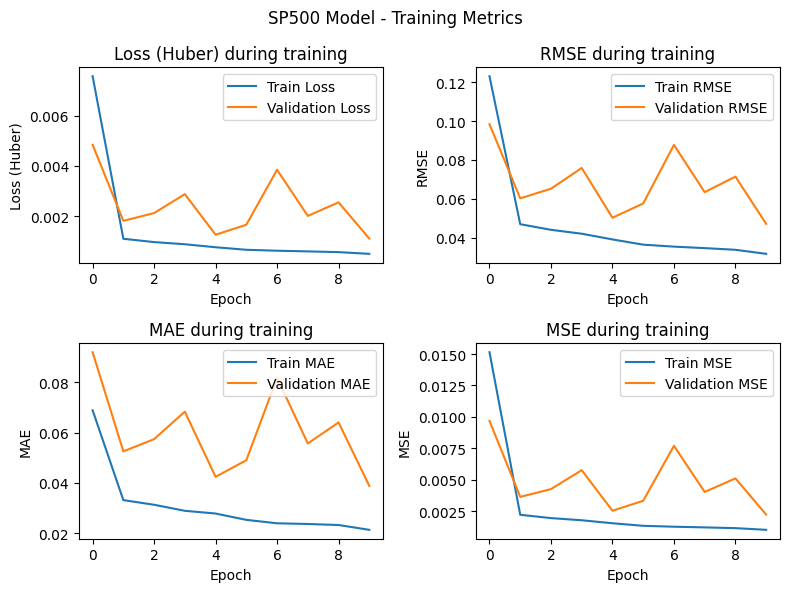

In [ ]:
print(history_final_values(history))
plot_history(history)

In [ ]:
# Model 8: CNNLSTM_ts120_4f_macd18-39-13

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 4 # features: Close + MACD + MACDSignal + MACDHist
time_step = 120
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
macd, macdsignal, macdhist = talib.MACD(close, fastperiod=18, slowperiod=39, signalperiod=13)
full = df_[['Close']].copy()
full['MACD'] = macd
full['MACDSignal'] = macdsignal
full['MACDHist'] = macdhist
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','MACD','MACDSignal', 'MACDHist']].copy()
df_features['Test'] = full.loc['2025':, ['Close','MACD','MACDSignal', 'MACDHist']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts120_4f_macd18-39-13")

# Compile and fit model, and store final metric values
history = compile_and_fit_model(model, X_train, y_train, X_validation, y_validation)
final_values4[model.name] = history_final_values(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
121/121 - 9s - 75ms/step - loss: 0.0075 - mae: 0.0676 - mse: 0.0151 - rmse: 0.1227 - val_loss: 0.0019 - val_mae: 0.0571 - val_mse: 0.0038 - val_rmse: 0.0617 - learning_rate: 0.0010
Epoch 2/50
121/121 - 3s - 26ms/step - loss: 0.0012 - mae: 0.0349 - mse: 0.0024 - rmse: 0.0493 - val_loss: 0.0049 - val_mae: 0.0940 - val_mse: 0.0099 - val_rmse: 0.0995 - learning_rate: 0.0010
Epoch 3/50
121/121 - 3s - 29ms/step - loss: 9.8145e-04 - mae: 0.0316 - mse: 0.0020 - rmse: 0.0443 - val_loss: 7.8592e-04 - val_mae: 0.0334 - val_mse: 0.0016 - val_rmse: 0.0396 - learning_rate: 0.0010
Epoch 4/50
121/121 - 3s - 23ms/step - loss: 8.8590e-04 - mae: 0.0296 - mse: 0.0018 - rmse: 0.0421 - val_loss: 0.0020 - val_mae: 0.0569 - val_mse: 0.0040 - val_rmse: 0.0636 - learning_rate: 5.0000e-04
Epoch 5/50
121/121 - 3s - 23ms/step - loss: 8.1157e-04 - mae: 0.0285 - mse: 0.0016 - rmse: 0.0403 - val_loss: 0.0076 - val_mae: 0.1184 - val_mse: 0.0153 - val_rmse: 0.1237 - learning_rate: 5.0000e-04
Epoch 6/50
121/1

{'loss': 0.000507, 'mae': 0.021823, 'mse': 0.001014, 'rmse': 0.031845, 'val_loss': 0.005249, 'val_mae': 0.09613, 'val_mse': 0.010498, 'val_rmse': 0.102462, 'learning_rate': 0.000125}


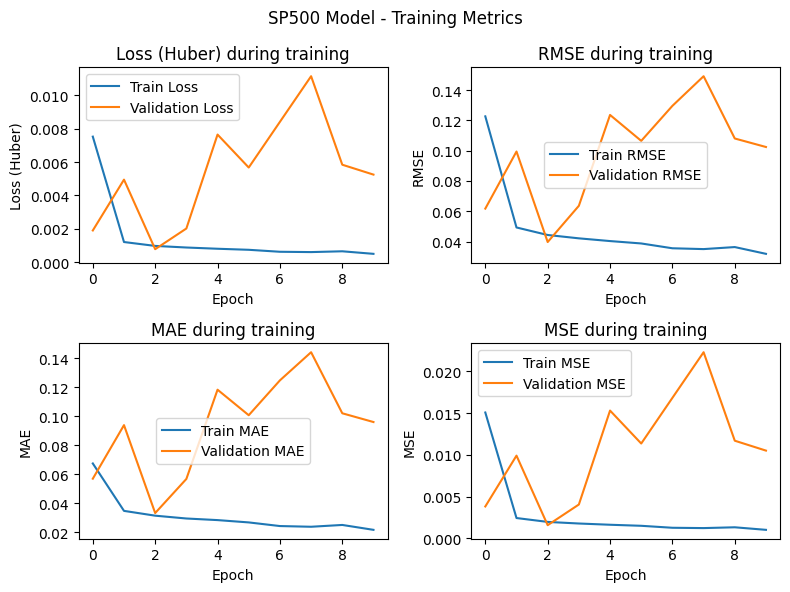

In [ ]:
print(history_final_values(history))
plot_history(history)

Display the training and validation results of solving model overfitting by using the `final_values4` dictionary.

In [ ]:
pd.DataFrame.from_dict(final_values4, orient="index")

,loss,mae,mse,rmse,val_loss,val_mae,val_mse,val_rmse,learning_rate
CNNLSTM_ts60_3f_sma50_rsi14,0.000263,0.015620,0.000526,0.022928,0.000195,0.015726,0.000391,0.019768,0.000125
CNNLSTM_ts120_3f_sma50_rsi14,0.000459,0.020156,0.000918,0.030297,0.003992,0.081555,0.007985,0.089357,0.000125
CNNLSTM_ts60_3f_sma20_rsi7,0.000437,0.019426,0.000874,0.029560,0.000252,0.017685,0.000504,0.022459,0.000125
CNNLSTM_ts120_3f_sma20_rsi7,0.000438,0.019841,0.000876,0.029590,0.001918,0.056399,0.003837,0.061943,0.000125
CNNLSTM_ts60_4f_macd12-26-9,0.000513,0.021379,0.001027,0.032041,0.000530,0.027327,0.001061,0.032573,0.000125
CNNLSTM_ts120_4f_macd12-26-9,0.000587,0.023195,0.001175,0.034275,0.004542,0.089996,0.009084,0.095310,0.000125
CNNLSTM_ts60_4f_macd18-39-13,0.000501,0.021315,0.001003,0.031662,0.001109,0.038805,0.002218,0.047092,0.000125
CNNLSTM_ts120_4f_macd18-39-13,0.000507,0.021823,0.001014,0.031845,0.005249,0.096130,0.010498,0.102462,0.000125


Choose CNNLSTM_ts60_3f_sma50_rsi14 model to do next step

## 10. Model Evaluation
The following code retrains the model CNNLSTM_ts60_3f_sma50_rsi14 and evaluates it using the test set.

### 10.1. Retain model

In [8]:
# Model CNNLSTM_ts60_3f_sma50_rsi14_retrain

df_features = {} # To hold the feature DataFrames for Train, Validation, and Test sets
features_num = 3 # features: Close + RSI + SMA
time_step = 60
# Compute features for the entire dataset
close = df_[['Close']].copy().values.astype(np.float64).flatten() # To ensure a clean 1D float array
sma50 = talib.SMA(close, timeperiod=50)
rsi14 = talib.RSI(close, timeperiod=14)
full = df_[['Close']].copy()
full['SMA50'] = sma50
full['RSI14'] = rsi14
full = full.dropna()
# Split using the same date borders as earlier
df_features['Train'] = full.loc[:'2023', ['Close','RSI14','SMA50']].copy()
df_features['Validation'] = full.loc['2024':'2024', ['Close','RSI14','SMA50']].copy()
df_features['Test'] = full.loc['2025':, ['Close','RSI14','SMA50']].copy()
# Scaling the datasets
transform_train, transform_validation, transform_test, scaler = scale_and_prepare_samples(df_features)
# Prepare LSTM training/validation/test samples
X_train, y_train, X_validation, y_validation, X_test, y_test = prepare_lstm_samples(transform_train, transform_validation, transform_test, features_num, time_step)

# Build model
model = keras.Sequential([
    Conv1D(filters=64, kernel_size=5, activation='relu', input_shape=(time_step, features_num)),
    MaxPooling1D(pool_size=2),
    Bidirectional(LSTM(units=256, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32, return_sequences=False)),
    Dropout(0.2),
    Dense(units=16),
    Dense(units=1)
], name="CNNLSTM_ts60_3f_sma50_rsi14_retrain")

# Check the model summary
model.summary()

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss = Huber(),
    metrics = [
        MeanAbsoluteError(name='mae'),
        RootMeanSquaredError(name='rmse'),
        MeanSquaredError(name='mse')
    ]
)
callbacks = [
    EarlyStopping(monitor='loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-7)
]
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
) # no validation_split

print(history_final_values(history))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNNLSTM_ts60_3f_sma50_rsi14_retrain"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 56, 64)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 28, 512)        │       657,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 28, 128)        │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 996,129 (3.80 MB)

 Trainable params: 996,129 (3.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
123/123 - 16s - 129ms/step - loss: 0.0029 - mae: 0.0485 - mse: 0.0058 - rmse: 0.0764 - learning_rate: 0.0010
Epoch 2/100
123/123 - 2s - 16ms/step - loss: 0.0011 - mae: 0.0313 - mse: 0.0021 - rmse: 0.0463 - learning_rate: 0.0010
Epoch 3/100
123/123 - 2s - 16ms/step - loss: 8.2384e-04 - mae: 0.0288 - mse: 0.0016 - rmse: 0.0406 - learning_rate: 0.0010
Epoch 4/100
123/123 - 3s - 21ms/step - loss: 8.8093e-04 - mae: 0.0292 - mse: 0.0018 - rmse: 0.0420 - learning_rate: 0.0010
Epoch 5/100
123/123 - 2s - 16ms/step - loss: 5.6775e-04 - mae: 0.0230 - mse: 0.0011 - rmse: 0.0337 - learning_rate: 0.0010
Epoch 6/100
123/123 - 3s - 21ms/step - loss: 5.3982e-04 - mae: 0.0229 - mse: 0.0011 - rmse: 0.0329 - learning_rate: 0.0010
Epoch 7/100
123/123 - 2s - 17ms/step - loss: 5.5192e-04 - mae: 0.0235 - mse: 0.0011 - rmse: 0.0332 - learning_rate: 0.0010
Epoch 8/100
123/123 - 2s - 16ms/step - loss: 4.5061e-04 - mae: 0.0208 - mse: 9.0123e-04 - rmse: 0.0300 - learning_rate: 0.0010
Epoch 9/100
123/12

### 10.2. Showing evaluated model's result
- using the test set
- using metric: MAE, MSE, RMSE
- Drawing charts to show the actual price and the predicted price over a period of around 1 year.

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
SP500 Model RMSE: 268.53
SP500 Model MSE: 72106.08
SP500 Model MAE: 258.66


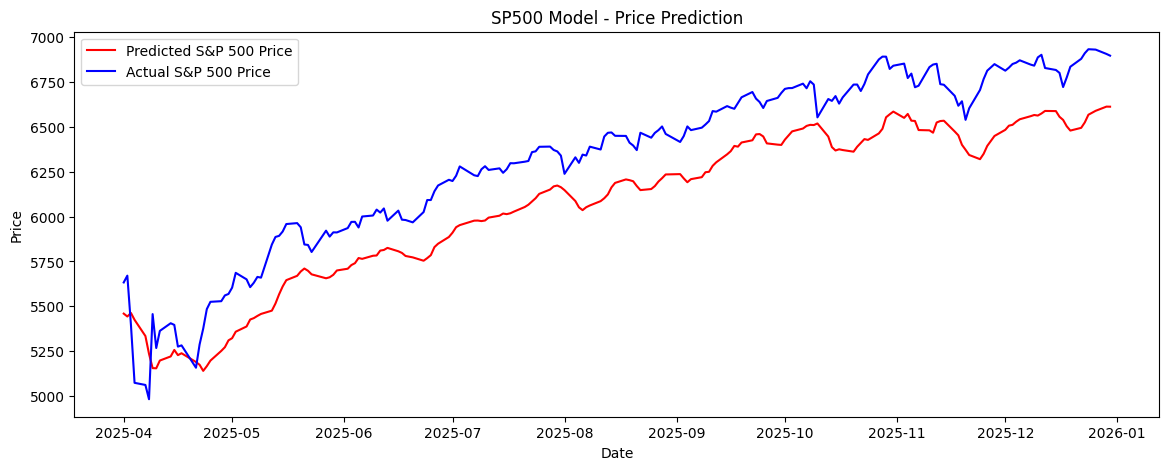

In [9]:
# Make predictions on the test set using the loaded model
predictions = model.predict(X_test)
predictions_full = np.zeros((len(predictions), features_num)) # Create a dummy array with The feature to match the scaler's expected input shape
predictions_full[:, 0] = predictions.flatten() # Place predictions in the first column (Close price)
y_pred = scaler.inverse_transform(predictions_full)[:, 0] # Inverse transform and take only Close price
#print(f"Predictions: {predictions_full[:5]}") # Check the prediction results
#print(f"Predictions: {y_pred[:5]}") # Check the prediction results

# Get the true values and inverse transform them as well
true = y_test
true_full = np.zeros((len(true), features_num)) # Create a dummy array with The feature to match the scaler's expected input shape
true_full[:, 0] = true.flatten()  # Place true in the first column (Close price)
y_true = scaler.inverse_transform(true_full)[:, 0]  # Inverse transform and take only Close price
#print(f"True values: {true_full[:5]}") # Check the true values results
#print(f"True Test value: {y_true[:5]}")  # Check the true value

# Calculate evaluation metrics
RMSE = root_mean_squared_error(y_true, y_pred)
MSE = mean_squared_error(y_true, y_pred)
MAE = mean_absolute_error(y_true, y_pred)

# Print the evaluation metrics
print(f'SP500 Model RMSE: {RMSE:.2f}')
print(f'SP500 Model MSE: {MSE:.2f}')
print(f'SP500 Model MAE: {MAE:.2f}')

# Visualize the results of price prediction
plt.figure(figsize=(14, 5))
plt.plot(df_.index[-len(y_true):], y_pred, color='red', label='Predicted S&P 500 Price')
plt.plot(df_.index[-len(y_true):], y_true, color='blue', label='Actual S&P 500 Price')
plt.title('SP500 Model - Price Prediction')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()


## 11. Export Models

In [10]:
# Create the 'models' directory if it doesn't exist
os.makedirs('models', exist_ok=True)

model_path = f"models/SP500_model.h5"
model.save(model_path)     # HDF5 format
print(f"Model for SP500 saved to {model_path}")

Model for SP500 saved to models/SP500_model.h5
